# Notebook 06: Cross-Species Homeostatic Microglia Transfer and Rank-Dynamics Analysis

## Study Overview
This notebook performs donor-aware transfer learning from human to mouse homeostatic microglia (subtype `1.5`) and evaluates gene- and module-level dynamics across a continuous transferred AD-like rank axis.

## Scientific Objectives
1. Train and validate a human AD-vs-Ctrl binary neural model in subtype `1.5`.
2. Transfer predicted `P(AD-like)` scores to matched mouse subtype `1.5` cells.
3. Quantify transcriptome changes across ranked transferred scores.
4. Identify dynamic gene modules and test functional enrichment.
5. Produce publication-ready summary figures and tabular outputs.

## Inputs
- Harmonized cross-species AnnData: `adatas/human_mouse_homeostatic_typed_nb05.h5ad`
- Humanized mouse microglia AnnData: `adatas/mouse_microglia_humanized_nb02.h5ad`
- Intermediate transfer artifacts generated in this notebook (Step 2).

## Methods at a Glance
- Standardization and filtering of homeostatic subtype labels.
- Donor-aware MLP classification with donor-stratified cross-validation.
- Mouse transfer scoring using `P(AD-like)` plus rank percentile.
- Rank-correlation analysis with Benjamini-Hochberg FDR control.
- KMeans-based module trajectory decomposition and module-rank association.
- ORA enrichment using GO, KEGG, Reactome, WikiPathways, and Jensen DISEASES.

## Reproducibility and Quality Notes
- `RANDOM_STATE = 42` is used for model training and clustering.
- Cells are organized as sequential pipeline stages; rerun in order for a clean state.
- Statistical outputs include adjusted p-values (FDR/BH) where applicable.
- Export and figure cells provide explicit file paths for generated artifacts.

## Expected Deliverables
- Probability tables and model artifacts for reuse.
- Enrichment workbook with global and module-specific sheets.
- Three-panel publication figure summarizing volcano, trajectory, and enrichment views.
- Console summary diagnostics for each major stage.

## Coding and Reporting Standards

This notebook is written to align with industry/academic production expectations:
- PEP8-oriented naming, spacing, and modular helper functions where practical in notebook context.
- Clear stage-wise docstrings and explicit variable contracts between steps.
- Defensive guards for missing prerequisites and shape mismatches.
- Explicit statistical reporting (`p`, adjusted `p`, effect direction, and module significance).
- Deterministic seeds for core model and clustering operations.
- Structured exports with stable filenames for manuscript and supplementary materials.

In [1]:
"""
Core imports shared across notebook sections.

Policy:
- Keep frequently used scientific imports centralized here.
- Keep specialized dependencies imported in the local cell where they are used.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.sparse as sp
from scipy import stats
from statsmodels.stats.multitest import multipletests

print("Core imports loaded: numpy, pandas, scipy, matplotlib, statsmodels.")

Core imports loaded: numpy, pandas, scipy, matplotlib, statsmodels.


In [ ]:
"""
Step 0a: Import harmonized AnnData handoff from Notebook 05.

This cell loads the primary harmonized AnnData object containing matched
human-mouse genes, species labels, homeostatic subtype annotations, and
disease/condition labels. The data have already been integrated via Scanorama
in Notebook 05 and are ready for immediate analysis.

Outputs:
    adata (AnnData): Full dataset with all species and subtypes
"""

import anndata as ad

# Define root directory for analysis
NOTEBOOK_DIR = Path.cwd().resolve()
if NOTEBOOK_DIR.name != "Notebooks":
    NOTEBOOK_DIR = (NOTEBOOK_DIR / "Notebooks").resolve()
ANALYSIS_ROOT = NOTEBOOK_DIR.parent.resolve()
RESULTS_PLOTS_DIR = ANALYSIS_ROOT / "Results" / "plots"
RESULTS_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
ADATA_PATH = ANALYSIS_ROOT / "adatas" / "human_mouse_homeostatic_typed_nb05.h5ad"

# Load the harmonized AnnData (all cells, all metadata)
adata = ad.read_h5ad(ADATA_PATH)

print(f"Loaded AnnData: {adata.shape}, layers: {list(adata.layers.keys())}")
print(f"Unique species: {adata.obs['species'].unique().tolist()}")
print(f"Unique subtypes: {adata.obs['homeostatic_subtype_label'].unique().tolist()}")

Loaded AnnData: (31451, 3578), layers: ['counts']
Unique species: ['Human', 'Mouse']
Unique subtypes: ['1.3', '1.0', '1.2', '1.5']


In [3]:
"""
Step 0b: Standardize subtype labels and remove subtype 1.2.

Human and mouse subtype annotations are stored in different columns.
We consolidate them into a single standardized 'mg_subtype' column using
the '1.#' format. Subtype 1.2 is excluded because it is inconsistently
represented across mouse samples. Only subtype 1.5 (homeostatic) is
used in downstream analyses.

Logic:
    - Human: use 'ident' column
    - Mouse: use 'predicted.homeostatic_subtype_label' column
    - Both: convert to '1.#' format and filter out '1.2'

Outputs:
    adata (AnnData): Updated with 'mg_subtype' column, 1.2 cells removed
"""

import re


def standardize_subtype(val):
    """
    Convert homeostatic subtype values to '1.#' format.

    Parameters:
        val: Subtype identifier (string, int, or other)

    Returns:
        str: Standardized subtype in '1.#' format, or original str if unmappable
    """
    if re.match(r"^1\.\d+$", str(val)):
        return str(val)
    try:
        intval = int(val)
        return f"1.{intval}"
    except (ValueError, TypeError):
        return str(val)


# Create mg_subtype: use 'ident' for human, 'predicted.homeostatic_subtype_label' for mouse
mg_subtype = np.where(
    adata.obs["species"] == "Human",
    adata.obs["ident"].apply(standardize_subtype),
    adata.obs["predicted.homeostatic_subtype_label"].apply(standardize_subtype),
)
adata.obs["mg_subtype"] = mg_subtype

# Filter out 1.2 cells (not present in all mouse samples)
adata = adata[adata.obs["mg_subtype"] != "1.2"].copy()

print("mg_subtype column standardized. Unique values:", sorted(adata.obs["mg_subtype"].unique()))
print(f"Filtered AnnData shape: {adata.shape}")

mg_subtype column standardized. Unique values: ['1.0', '1.3', '1.5']
Filtered AnnData shape: (23242, 3578)


In [4]:
"""
Step 0c: Split harmonized AnnData into species-specific objects.

Partition the full dataset into human and mouse subsets. Both retain all
metadata columns, layers (counts, lognorm, scanorama), and gene information
from the harmonized reference.

Outputs:
    human_adata (AnnData): Human cells only
    mouse_adata (AnnData): Mouse cells only
"""

human_adata = adata[adata.obs["species"] == "Human"].copy()
mouse_adata = adata[adata.obs["species"] == "Mouse"].copy()

print(f"human_adata shape: {human_adata.shape}, mg_subtype: {sorted(human_adata.obs['mg_subtype'].unique())}")
print(f"mouse_adata shape: {mouse_adata.shape}, mg_subtype: {sorted(mouse_adata.obs['mg_subtype'].unique())}")


human_adata shape: (22973, 3578), mg_subtype: ['1.0', '1.3', '1.5']
mouse_adata shape: (269, 3578), mg_subtype: ['1.0', '1.3', '1.5']


## Section 1: Exploratory Analysis – C1QA Expression by Condition and Subtype

**Goal:** Quantify baseline differences in C1QA expression (a key complement component biomarker in neuroinflammation) between Mock- and OG-stimulated mouse homeostatic microglia, stratified by subtype.

**Approach:**
- Pooled violin plots overlaid with per-sample pseudobulk means (diamonds) and statistical t-test results
- Group means with standard error bars visualized by condition and subtype
- Two-way ANOVA to assess main effects of condition and subtype


In [5]:
# Section 1 uses the shared core imports loaded near the top of the notebook.
print("Section 1 core imports are available.")

Section 1 core imports are available.


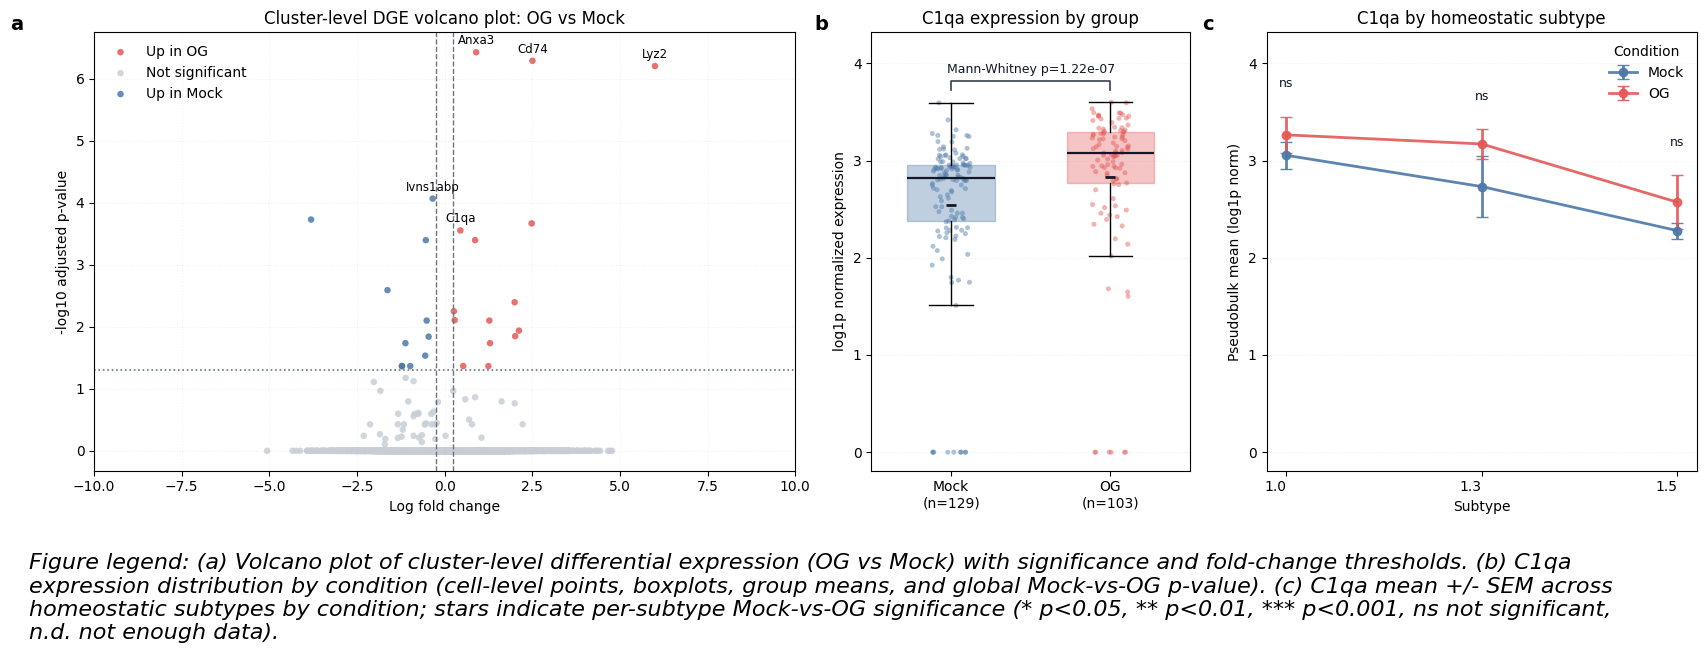

Cluster-level DGE summary for 5312 Microglia NN_1
Groups compared: OG vs Mock
Cell counts: {'Mock': 129, 'OG': 103}
C1qa logFC: 0.448189
C1qa raw p-value: 1.22225e-07
C1qa adjusted p-value: 0.000279948

Panel B (C1qa expression) group statistics:
Mann-Whitney U (OG vs Mock): U=3.96e+03, p=1.22e-07
Welch t-test (OG vs Mock): t=-2.71, p=0.00728
Mean difference (OG - Mock): 0.2894
Median difference (OG - Mock): 0.2632

Panel C (homeostatic subtype summary):
Subtypes shown: 3
Sample column used: Sample
Subtype source: mouse_adata
Subtype labels mapped to cluster cells: 221

Panel C subtype-wise Mock vs OG significance:
subtype  n_mock  n_og  p_welch  p_mannwhitney sig_label
    1.0       3     3   0.4193            0.7        ns
    1.3       3     3   0.2956            0.2        ns
    1.5       3     3   0.4019            0.7        ns

Top positive logFC genes:
    gene   logFC     p_adj
   Anxa3  0.8998 3.752e-07
    Cd74   2.506 5.153e-07
    Lyz2   6.001 6.266e-07
Ivns1abp -0.3414 8

In [6]:
# DGE-style visualization for the cluster-level OG vs Mock comparison.
import scanpy as sc
import scipy.sparse as sp
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import textwrap

analysis_root = str(ANALYSIS_ROOT)
allcells_path = str(ANALYSIS_ROOT / "adatas" / "brain_microglia_allgenes.h5ad")
cluster_col = "cluster_name"
group_col = "Condition"
subtype_col = "homeostatic_subtype_label"
cluster_label = "5312 Microglia NN_1"

adata_all = sc.read_h5ad(allcells_path)

required_obs = {cluster_col, group_col}
missing_obs = sorted(required_obs.difference(adata_all.obs.columns))
if missing_obs:
    raise RuntimeError(f"Missing required obs columns in {allcells_path}: {missing_obs}")

gene_lookup = {g.lower(): g for g in adata_all.var_names}
if "c1qa" not in gene_lookup:
    raise RuntimeError("C1qa/C1QA not found in adata.var_names")
gene_name = gene_lookup["c1qa"]

cluster_mask = adata_all.obs[cluster_col].astype(str).eq(cluster_label)
adata_plot = adata_all[cluster_mask].copy()
if adata_plot.n_obs == 0:
    raise RuntimeError(f"Cluster '{cluster_label}' was not found in {cluster_col}")

adata_plot.obs[group_col] = adata_plot.obs[group_col].astype(str).str.strip()
all_groups = adata_plot.obs[group_col].value_counts().index.tolist()
if "OG" in all_groups and "Mock" in all_groups:
    group_order = ["Mock", "OG"]
else:
    group_order = all_groups[:2]
if len(group_order) < 2:
    raise RuntimeError(f"Need at least two groups in '{group_col}' for DGE testing")
adata_plot = adata_plot[adata_plot.obs[group_col].isin(group_order)].copy()

# Transfer subtype labels into adata_plot when missing, using barcode-key joins.
def _barcode_key(index_like):
    return (
        pd.Index(index_like)
        .astype(str)
        .str.replace(r"^Mouse_", "", regex=True)
        .str.strip()
    )

subtype_transfer_source = "already present"
subtype_mapped_n = int(adata_plot.obs[subtype_col].notna().sum()) if subtype_col in adata_plot.obs.columns else 0
if subtype_col not in adata_plot.obs.columns:
    subtype_transfer_source = "not found"
    target_key = _barcode_key(adata_plot.obs_names)
    for src_name in ["mouse_adata", "adata", "humanized_micro_adata"]:
        if src_name not in globals():
            continue
        src = globals()[src_name]
        if not hasattr(src, "obs") or subtype_col not in src.obs.columns:
            continue

        src_key = _barcode_key(src.obs_names)
        src_map = pd.DataFrame(
            {
                "_key": src_key.to_numpy(),
                "_subtype": src.obs[subtype_col].astype(str).values,
            }
        )
        src_map = src_map.drop_duplicates(subset=["_key"], keep="first").set_index("_key")

        mapped = pd.Series(target_key, index=adata_plot.obs_names).map(src_map["_subtype"])
        mapped = mapped.replace({"nan": np.nan, "None": np.nan, "": np.nan})
        n_mapped = int(mapped.notna().sum())
        if n_mapped > 0:
            adata_plot.obs[subtype_col] = mapped.values
            subtype_transfer_source = src_name
            subtype_mapped_n = n_mapped
            break

group_counts = adata_plot.obs[group_col].value_counts().reindex(group_order).fillna(0).astype(int)

ad_de = adata_plot.copy()
if "counts" in ad_de.layers:
    ad_de.X = ad_de.layers["counts"].copy()
sc.pp.normalize_total(ad_de, target_sum=1e4)
if sp.issparse(ad_de.X):
    ad_de.X = ad_de.X.tocsr(copy=True)
    ad_de.X.data = np.log1p(ad_de.X.data)
else:
    ad_de.X = np.log1p(np.asarray(ad_de.X))
ad_de.uns["log1p"] = {"base": None}

sc.tl.rank_genes_groups(
    ad_de,
    groupby=group_col,
    groups=[group_order[1]],
    reference=group_order[0],
    method="wilcoxon",
    n_genes=ad_de.shape[1],
    key_added="cluster_dge",
)

rgg = sc.get.rank_genes_groups_df(ad_de, group=group_order[1], key="cluster_dge")
volcano_df = rgg.rename(columns={"names": "gene", "logfoldchanges": "logFC", "pvals": "p_val", "pvals_adj": "p_adj"}).copy()
volcano_df["p_adj"] = volcano_df["p_adj"].clip(lower=np.finfo(float).tiny)
volcano_df["neg_log10_padj"] = -np.log10(volcano_df["p_adj"])
volcano_df["sig"] = "Not significant"
volcano_df.loc[(volcano_df["p_adj"] < 0.05) & (volcano_df["logFC"] >= 0.25), "sig"] = f"Up in {group_order[1]}"
volcano_df.loc[(volcano_df["p_adj"] < 0.05) & (volcano_df["logFC"] <= -0.25), "sig"] = f"Up in {group_order[0]}"

c1qa_row = volcano_df[volcano_df["gene"].astype(str).str.lower() == gene_name.lower()]
if c1qa_row.empty:
    raise RuntimeError(f"{gene_name} was not returned by rank_genes_groups")
c1qa_row = c1qa_row.iloc[0]

label_df = pd.concat([
    volcano_df.nsmallest(4, "p_adj"),
    volcano_df[volcano_df["gene"].astype(str).eq(gene_name)],
], ignore_index=True).drop_duplicates(subset=["gene"])

palette = {
    "Not significant": "#C9CED6",
    f"Up in {group_order[0]}": "#4C78A8",
    f"Up in {group_order[1]}": "#E45756",
}

c1qa_idx = np.where(ad_de.var_names == gene_name)[0]
if len(c1qa_idx) == 0:
    raise RuntimeError(f"{gene_name} not found in ad_de.var_names")
c1qa_idx = int(c1qa_idx[0])
c1qa_expr = ad_de.X[:, c1qa_idx]
if sp.issparse(c1qa_expr):
    c1qa_expr = np.asarray(c1qa_expr.toarray()).ravel()
else:
    c1qa_expr = np.asarray(c1qa_expr).ravel()

expr_df = pd.DataFrame({
    group_col: ad_de.obs[group_col].astype(str).values,
    "expr": c1qa_expr,
})
if subtype_col in ad_de.obs.columns:
    expr_df[subtype_col] = ad_de.obs[subtype_col].to_numpy()
    expr_df[subtype_col] = expr_df[subtype_col].astype(object)
    expr_df.loc[expr_df[subtype_col].astype(str).isin(["nan", "None", ""]), subtype_col] = np.nan

sample_candidates = ["Sample", "sample", "orig.ident", "sample_id", "donor", "Donor"]
sample_col = next((c for c in sample_candidates if c in ad_de.obs.columns), None)
if sample_col is not None:
    expr_df["_sample_id"] = ad_de.obs[sample_col].astype(str).values

expr_df = expr_df[expr_df[group_col].isin(group_order)].copy()

fig, (ax_vol, ax_expr, ax_sub) = plt.subplots(
    1,
    3,
    figsize=(17.0, 6.0),
    gridspec_kw={"width_ratios": [2.2, 1.0, 1.35]},
)

# Panel A: volcano
for label, sub in volcano_df.groupby("sig", sort=False):
    ax_vol.scatter(
        sub["logFC"],
        sub["neg_log10_padj"],
        s=22,
        alpha=0.85,
        color=palette[label],
        edgecolor="none",
        label=label,
    )

ax_vol.axhline(-np.log10(0.05), color="#6B7280", linestyle=":", linewidth=1.2)
ax_vol.axvline(-0.25, color="#6B7280", linestyle="--", linewidth=1.0)
ax_vol.axvline(0.25, color="#6B7280", linestyle="--", linewidth=1.0)
ax_vol.set_xlim(-10, 10)

for _, row in label_df.iterrows():
    ax_vol.text(
        row["logFC"],
        row["neg_log10_padj"] + 0.08,
        str(row["gene"]),
        fontsize=8.5,
        ha="center",
        va="bottom",
    )

ax_vol.set_title(f"Cluster-level DGE volcano plot: {group_order[1]} vs {group_order[0]}")
ax_vol.set_xlabel("Log fold change")
ax_vol.set_ylabel("-log10 adjusted p-value")
ax_vol.grid(alpha=0.18, linestyle=":")
ax_vol.legend(frameon=False, loc="upper left")
ax_vol.text(-0.12, 1.04, "a", transform=ax_vol.transAxes, fontsize=14, fontweight="bold", ha="left", va="top")

# Panel B: C1qa expression by condition
positions = np.arange(len(group_order))
group_expr = [expr_df.loc[expr_df[group_col].eq(g), "expr"].to_numpy() for g in group_order]
group_colors = [palette.get(f"Up in {g}", "#9CA3AF") for g in group_order]

bp = ax_expr.boxplot(
    group_expr,
    positions=positions,
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "#111827", "linewidth": 1.6},
)
for box, color in zip(bp["boxes"], group_colors):
    box.set_facecolor(color)
    box.set_alpha(0.35)
    box.set_edgecolor(color)

rng = np.random.default_rng(7)
for i, vals in enumerate(group_expr):
    if vals.size == 0:
        continue
    jitter = rng.uniform(-0.12, 0.12, size=vals.size)
    ax_expr.scatter(
        np.full(vals.size, positions[i]) + jitter,
        vals,
        s=13,
        alpha=0.45,
        color=group_colors[i],
        edgecolor="none",
    )

mean_vals = [np.mean(vals) if vals.size > 0 else np.nan for vals in group_expr]
for i, mean_val in enumerate(mean_vals):
    if np.isfinite(mean_val):
        ax_expr.scatter(positions[i], mean_val, s=58, color="#111827", marker="_", linewidths=2.0, zorder=5)

stats_summary = {}
if len(group_expr) >= 2 and group_expr[0].size > 0 and group_expr[1].size > 0:
    vals_a, vals_b = group_expr[0], group_expr[1]
    mw = stats.mannwhitneyu(vals_a, vals_b, alternative="two-sided")
    welch = stats.ttest_ind(vals_a, vals_b, equal_var=False, nan_policy="omit")
    stats_summary = {
        "group_a": group_order[0],
        "group_b": group_order[1],
        "mw_u": float(mw.statistic),
        "mw_p": float(mw.pvalue),
        "welch_t": float(welch.statistic),
        "welch_p": float(welch.pvalue),
        "median_diff_b_minus_a": float(np.median(vals_b) - np.median(vals_a)),
        "mean_diff_b_minus_a": float(np.mean(vals_b) - np.mean(vals_a)),
    }

    finite_vals = np.concatenate([v[np.isfinite(v)] for v in [vals_a, vals_b]])
    if finite_vals.size > 0:
        y_min, y_max = np.nanmin(finite_vals), np.nanmax(finite_vals)
        span = max(0.25, y_max - y_min)
        y_bracket = y_max + 0.06 * span
        y_tip = y_bracket - 0.025 * span
        ax_expr.plot(
            [positions[0], positions[0], positions[1], positions[1]],
            [y_tip, y_bracket, y_bracket, y_tip],
            color="#374151",
            linewidth=1.2,
        )
        ax_expr.text(
            np.mean([positions[0], positions[1]]),
            y_bracket + 0.015 * span,
            f"Mann-Whitney p={stats_summary['mw_p']:.2e}",
            ha="center",
            va="bottom",
            fontsize=9,
            color="#111827",
        )
        ax_expr.set_ylim(top=y_bracket + 0.14 * span)

ax_expr.set_xticks(positions)
ax_expr.set_xticklabels([f"{g}\n(n={int(group_counts.get(g, 0))})" for g in group_order])
ax_expr.set_title(f"{gene_name} expression by group")
ax_expr.set_ylabel("log1p normalized expression")
ax_expr.grid(alpha=0.18, linestyle=":", axis="y")
ax_expr.text(-0.18, 1.04, "b", transform=ax_expr.transAxes, fontsize=14, fontweight="bold", ha="left", va="top")

# Panel C: C1qa by homeostatic subtype + per-subtype significance
panel_c_stats = {}
subtype_sig_df = pd.DataFrame()
if subtype_col in expr_df.columns:
    sub_df = expr_df.copy()
    subtype_str = sub_df[subtype_col].astype(str).str.strip()
    valid_mask = ~subtype_str.str.lower().isin(["nan", "none", ""])
    sub_df = sub_df.loc[valid_mask].copy()
    sub_df[subtype_col] = subtype_str.loc[valid_mask].values
    subtype_order = sorted(sub_df[subtype_col].unique())

    if sample_col is not None and "_sample_id" in sub_df.columns:
        pb_sub = (
            sub_df.groupby([subtype_col, group_col, "_sample_id"], observed=True)["expr"]
            .mean()
            .reset_index(name="mean_expr")
        )
        sub_stats = (
            pb_sub.groupby([subtype_col, group_col], observed=True)["mean_expr"]
            .agg(group_mean="mean", group_sem="sem")
            .reset_index()
        )
        test_df = pb_sub.copy()
    else:
        sub_stats = (
            sub_df.groupby([subtype_col, group_col], observed=True)["expr"]
            .agg(group_mean="mean", group_sem="sem")
            .reset_index()
        )
        test_df = sub_df.rename(columns={"expr": "mean_expr"}).copy()

    x = np.arange(len(subtype_order))
    for cond in group_order:
        cond_sub = (
            sub_stats[sub_stats[group_col].eq(cond)]
            .set_index(subtype_col)
            .reindex(subtype_order)
        )
        y = cond_sub["group_mean"].to_numpy()
        yerr = cond_sub["group_sem"].fillna(0.0).to_numpy()
        ax_sub.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="o-",
            color=palette.get(f"Up in {cond}", "#6B7280"),
            capsize=4,
            lw=2,
            ms=6,
            alpha=0.9,
            label=cond,
        )

    ax_sub.set_xticks(x)
    ax_sub.set_xticklabels(subtype_order, rotation=0, ha="right")
    ax_sub.set_title("C1qa by homeostatic subtype")
    ax_sub.set_xlabel("Subtype")
    if sample_col is not None:
        ax_sub.set_ylabel("Pseudobulk mean (log1p norm)")
    else:
        ax_sub.set_ylabel("Mean +/- SEM (log1p norm)")
    ax_sub.set_ylim(ax_expr.get_ylim())
    ax_sub.grid(alpha=0.18, linestyle=":", axis="y")
    ax_sub.legend(title="Condition", frameon=False, loc="best")
    ax_sub.text(-0.15, 1.04, "c", transform=ax_sub.transAxes, fontsize=14, fontweight="bold", ha="left", va="top")

    # Per-subtype significance tests (Mock vs OG)
    subtype_rows = []
    for i, subtype in enumerate(subtype_order):
        vals_mock = test_df.loc[(test_df[subtype_col].eq(subtype)) & (test_df[group_col].eq(group_order[0])), "mean_expr"].dropna().to_numpy()
        vals_og = test_df.loc[(test_df[subtype_col].eq(subtype)) & (test_df[group_col].eq(group_order[1])), "mean_expr"].dropna().to_numpy()

        p_welch = np.nan
        if len(vals_mock) >= 2 and len(vals_og) >= 2:
            p_welch = float(stats.ttest_ind(vals_mock, vals_og, equal_var=False, nan_policy="omit").pvalue)

        p_mw = np.nan
        if len(vals_mock) >= 1 and len(vals_og) >= 1:
            p_mw = float(stats.mannwhitneyu(vals_mock, vals_og, alternative="two-sided").pvalue)

        chosen_p = p_welch if np.isfinite(p_welch) else p_mw
        if np.isfinite(chosen_p):
            if chosen_p < 1e-3:
                sig_label = "***"
            elif chosen_p < 1e-2:
                sig_label = "**"
            elif chosen_p < 5e-2:
                sig_label = "*"
            else:
                sig_label = "ns"
        else:
            sig_label = "n.d."

        subtype_rows.append(
            {
                "subtype": subtype,
                "n_mock": int(len(vals_mock)),
                "n_og": int(len(vals_og)),
                "p_welch": p_welch,
                "p_mannwhitney": p_mw,
                "sig_label": sig_label,
            }
        )

        if sig_label != "n.d.":
            cond_sub = (
                sub_stats[sub_stats[subtype_col].eq(subtype)]
                .set_index(group_col)
                .reindex(group_order)
            )
            y_top_sub = np.nanmax((cond_sub["group_mean"] + cond_sub["group_sem"].fillna(0.0)).to_numpy())
            y0, y1 = ax_sub.get_ylim()
            y_text = min(y1 - 0.04 * (y1 - y0), y_top_sub + 0.06 * (y1 - y0))
            ax_sub.text(i, y_text, sig_label, ha="center", va="bottom", fontsize=9, color="#111827")

    subtype_sig_df = pd.DataFrame(subtype_rows)

    panel_c_stats = {
        "n_subtypes": len(subtype_order),
        "sample_col": sample_col if sample_col is not None else "None (cell-level summary)",
        "subtype_transfer_source": subtype_transfer_source,
        "subtype_mapped_n": subtype_mapped_n,
    }
else:
    ax_sub.text(
        0.5,
        0.5,
        f"'{subtype_col}' not found\nin this dataset",
        ha="center",
        va="center",
        fontsize=11,
    )
    ax_sub.set_axis_off()

caption = textwrap.fill(
    "Figure legend: (a) Volcano plot of cluster-level differential expression (OG vs Mock) with significance and fold-change thresholds. "
    "(b) C1qa expression distribution by condition (cell-level points, boxplots, group means, and global Mock-vs-OG p-value). "
    "(c) C1qa mean +/- SEM across homeostatic subtypes by condition; stars indicate per-subtype Mock-vs-OG significance "
    "(* p<0.05, ** p<0.01, *** p<0.001, ns not significant, n.d. not enough data).",
    width=140,
)
fig.text(0.01, -0.08, caption, ha="left", va="bottom", fontsize=16, style="italic")

plt.tight_layout(rect=[0, 0.11, 1, 1])
plt.show()

# Save the figure as SVG in the 'figure' folder
fig.savefig(RESULTS_PLOTS_DIR / "mouse_homeostatic+subtype_c1qa_expression_nb06.svg", format="svg", bbox_inches="tight")

print("=" * 96)
print(f"Cluster-level DGE summary for {cluster_label}")
print("=" * 96)
print(f"Groups compared: {group_order[1]} vs {group_order[0]}")
print(f"Cell counts: {group_counts.to_dict()}")
print(f"C1qa logFC: {c1qa_row['logFC']:.6g}")
print(f"C1qa raw p-value: {c1qa_row['p_val']:.6g}")
print(f"C1qa adjusted p-value: {c1qa_row['p_adj']:.6g}")
print()
if stats_summary:
    print("Panel B (C1qa expression) group statistics:")
    print(f"Mann-Whitney U ({stats_summary['group_b']} vs {stats_summary['group_a']}): U={stats_summary['mw_u']:.3g}, p={stats_summary['mw_p']:.3g}")
    print(f"Welch t-test ({stats_summary['group_b']} vs {stats_summary['group_a']}): t={stats_summary['welch_t']:.3g}, p={stats_summary['welch_p']:.3g}")
    print(f"Mean difference ({stats_summary['group_b']} - {stats_summary['group_a']}): {stats_summary['mean_diff_b_minus_a']:.4f}")
    print(f"Median difference ({stats_summary['group_b']} - {stats_summary['group_a']}): {stats_summary['median_diff_b_minus_a']:.4f}")
    print()
if panel_c_stats:
    print("Panel C (homeostatic subtype summary):")
    print(f"Subtypes shown: {panel_c_stats['n_subtypes']}")
    print(f"Sample column used: {panel_c_stats['sample_col']}")
    print(f"Subtype source: {panel_c_stats['subtype_transfer_source']}")
    print(f"Subtype labels mapped to cluster cells: {panel_c_stats['subtype_mapped_n']}")
    print()
if not subtype_sig_df.empty:
    print("Panel C subtype-wise Mock vs OG significance:")
    print(subtype_sig_df.to_string(index=False, float_format=lambda x: f"{x:.4g}"))
    print()
print("Top positive logFC genes:")
print(volcano_df.sort_values(["p_adj", "logFC"], ascending=[True, False]).head(10)[["gene", "logFC", "p_adj"]].to_string(index=False, float_format=lambda x: f"{x:.4g}"))

## Section 1b: Export Microglia DGE

In [7]:
# inspect
volcano_df.sort_values("p_adj").head(20)

# export
volcano_df.to_csv(f"{ANALYSIS_ROOT}/Results/DGE/Microglia_cluster_DGE_OGvsMock_nb06.csv", index=False)  

# Step 2: ML Model

## Model Record (Locked-In Version)

This is the selected model configuration for this notebook run.

- Model family: `sklearn.neural_network.MLPClassifier`, a feed-forward multilayer perceptron neural network.
- Biological scope: human and mouse homeostatic microglia subtype `1.5` only.
- Label task (human): binary `AD` vs `Ctrl` from `Study_Designation`.
- Transfer target (mouse): continuous transferred `P(AD-like)` score plus rank-based ordering.

### Compact History of What We Did

- Started from poor-performing transfer variants and iterated multiple approaches.
- Settled on donor-aware human-to-mouse binary neural transfer as the working model.
- Added ranked-score visualization and C1QA trend readouts, including rolling SEM ribbons.
- Final decision in this run: include all stable shared genes in training (no C1Q exclusion).
- Code cleanup: removed tertile binning and tertile-specific summaries to keep a continuous-only analysis path.

### Exact Data/Feature Pipeline Parameters

- `SUBTYPE_TARGET = "1.5"`
- `HUMAN_LABEL_COL = "Study_Designation"`
- `MOUSE_LABEL_COL = "Condition"`
- `RANDOM_STATE = 42`
- Gene exclusion set: `EXCLUDE_GENES = set()` (no excluded genes)
- Shared gene space: intersection of human and mouse var names
- Stable-gene filters:
  - human detect rate `>= 0.02`
  - mouse detect rate `>= 0.02`
  - absolute detect-rate difference `<= 0.45`
  - absolute log10 variance ratio `<= 1.20`
- Normalization used for model input: per-cell library-size scaling to `1e4`, then `log1p`
- Human sample weighting: inverse class frequency x inverse donor frequency, then normalized to mean `1.0`

### Exact Training Parameters

- CV split design: donor-stratified using donor-level labels (`y_donor = mean(y) >= 0.5`)
- Number of folds: `n_splits = min(5, min_class_donors)` (current run used 5)
- Per-fold preprocessing: `StandardScaler(with_mean=True, with_std=True)`
- CV model (`MLPClassifier`) hyperparameters:
  - `hidden_layer_sizes=(128, 64, 16)`
  - `activation="relu"`
  - `solver="adam"`
  - `alpha=1e-3`
  - `learning_rate_init=5e-4`
  - `batch_size=128`
  - `max_iter=400`
  - `early_stopping=True`
  - `n_iter_no_change=25`
  - `random_state=RANDOM_STATE + fold_i`
- Final fit model hyperparameters (same architecture):
  - `max_iter=450`
  - `random_state=RANDOM_STATE`

### Exact Outputs Produced

- Human CV output: `human_transfer_df["cv_p_ad_like"]`
- Mouse transfer outputs:
  - `mouse_transfer_df["p_ad_like"]`
  - `mouse_transfer_df["p_ad_like_score_01"]`
  - `mouse_transfer_df["p_ad_like_rank_pct"]`

## Step 2a: Human Binary Neural Transfer Model

Train a donor-aware multilayer perceptron (MLP) on human subtype `1.5` cells to distinguish `AD` vs `Ctrl` using all stable shared genes (no exclusions), then transfer predicted `P(AD-like)` to mouse subtype `1.5` cells.

In [8]:
"""
Step 2a-i: Prepare shared features for a human AD-vs-Ctrl neural transfer model.
"""

SUBTYPE_TARGET = "1.5"
HUMAN_LABEL_COL = "Study_Designation"
MOUSE_LABEL_COL = "Condition"
RANDOM_STATE = 42
EXCLUDE_GENES = set()

DONOR_CANDIDATES = [
    "Donor",
    "donor",
    "donor_id",
    "donorID",
    "subject_id",
    "Subject",
    "orig.ident",
    "Sample",
    "sample",
]
MOUSE_SAMPLE_CANDIDATES = ["Sample", "sample", "orig.ident"]


def pick_first_existing(obs_df, candidates, fallback_name):
    for c in candidates:
        if c in obs_df.columns:
            return c
    return fallback_name


def map_human_label(v):
    s = str(v).strip().lower()
    if s in {"nan", "none", ""}:
        return np.nan
    if any(k in s for k in ["ad", "alz", "alzheimer"]):
        return "AD"
    if any(k in s for k in ["ctrl", "control", "healthy", "normal", "nd"]):
        return "Ctrl"
    return np.nan


def normalize_log1p(x):
    lib = np.sum(x, axis=1, keepdims=True)
    lib = np.maximum(lib, 1e-8)
    x_norm = (x / lib) * 1e4
    return np.log1p(x_norm)


human_sub = human_adata[human_adata.obs["homeostatic_subtype_label"].astype(str) == SUBTYPE_TARGET].copy()
mouse_sub = mouse_adata[mouse_adata.obs["homeostatic_subtype_label"].astype(str) == SUBTYPE_TARGET].copy()

human_donor_col = pick_first_existing(human_sub.obs, DONOR_CANDIDATES, "_fallback_donor")
mouse_sample_col = pick_first_existing(mouse_sub.obs, MOUSE_SAMPLE_CANDIDATES, "_fallback_sample")

if human_donor_col == "_fallback_donor":
    human_sub.obs[human_donor_col] = [f"donor_{i}" for i in range(human_sub.n_obs)]
if mouse_sample_col == "_fallback_sample":
    mouse_sub.obs[mouse_sample_col] = [f"sample_{i}" for i in range(mouse_sub.n_obs)]

human_sub.obs["disease_label"] = human_sub.obs[HUMAN_LABEL_COL].apply(map_human_label)
human_sub = human_sub[human_sub.obs["disease_label"].notna()].copy()
mouse_sub = mouse_sub[mouse_sub.obs[MOUSE_LABEL_COL].notna()].copy()

shared_all = sorted(set(human_sub.var_names).intersection(set(mouse_sub.var_names)))
shared_genes = [g for g in shared_all if g not in EXCLUDE_GENES]

Xh_all = human_sub[:, shared_genes].X
Xm_all = mouse_sub[:, shared_genes].X
if sp.issparse(Xh_all):
    h_detect = np.asarray((Xh_all > 0).mean(axis=0)).ravel()
    h_mu = np.asarray(Xh_all.mean(axis=0)).ravel()
    h_mu2 = np.asarray(Xh_all.power(2).mean(axis=0)).ravel()
    h_var = np.maximum(h_mu2 - np.square(h_mu), 1e-12)
else:
    h_detect = np.asarray((Xh_all > 0).mean(axis=0)).ravel()
    h_var = np.maximum(np.asarray(Xh_all.var(axis=0)).ravel(), 1e-12)

if sp.issparse(Xm_all):
    m_detect = np.asarray((Xm_all > 0).mean(axis=0)).ravel()
    m_mu = np.asarray(Xm_all.mean(axis=0)).ravel()
    m_mu2 = np.asarray(Xm_all.power(2).mean(axis=0)).ravel()
    m_var = np.maximum(m_mu2 - np.square(m_mu), 1e-12)
else:
    m_detect = np.asarray((Xm_all > 0).mean(axis=0)).ravel()
    m_var = np.maximum(np.asarray(Xm_all.var(axis=0)).ravel(), 1e-12)

detect_diff = np.abs(h_detect - m_detect)
log_var_ratio = np.abs(np.log10(h_var / m_var))
stable_mask = (h_detect >= 0.02) & (m_detect >= 0.02) & (detect_diff <= 0.45) & (log_var_ratio <= 1.20)
stable_genes = [g for g, keep in zip(shared_genes, stable_mask) if keep]

if len(stable_genes) < 500:
    raise RuntimeError(f"Too few stable genes after filtering: {len(stable_genes)}")

X_h = human_sub[:, stable_genes].X
X_m = mouse_sub[:, stable_genes].X
X_h = X_h.toarray() if sp.issparse(X_h) else np.asarray(X_h)
X_m = X_m.toarray() if sp.issparse(X_m) else np.asarray(X_m)
X_h_proc = normalize_log1p(X_h)
X_m_proc = normalize_log1p(X_m)

human_meta = pd.DataFrame(
    {
        "disease_label": human_sub.obs["disease_label"].astype(str).values,
        "donor": human_sub.obs[human_donor_col].astype(str).values,
    }
)
human_meta["y"] = (human_meta["disease_label"] == "AD").astype(int)
mouse_meta = pd.DataFrame(
    {
        "condition": mouse_sub.obs[MOUSE_LABEL_COL].astype(str).values,
        "sample": mouse_sub.obs[mouse_sample_col].astype(str).values,
    }
)

class_counts = human_meta["disease_label"].value_counts().to_dict()
donor_counts = human_meta["donor"].value_counts().to_dict()
class_w = human_meta["disease_label"].map(lambda c: 1.0 / max(class_counts.get(c, 1), 1)).to_numpy()
donor_w = human_meta["donor"].map(lambda d: 1.0 / max(donor_counts.get(d, 1), 1)).to_numpy()
sample_weight_h = class_w * donor_w
sample_weight_h = sample_weight_h / np.mean(sample_weight_h)

y_h = human_meta["y"].to_numpy()
groups_h = human_meta["donor"].astype(str).to_numpy()

print("=" * 80)
print("Step 2a binary-transfer setup complete")
print("=" * 80)
print(f"Human donor column used: {human_donor_col}")
print(f"Mouse sample column used: {mouse_sample_col}")
print(f"Human subtype {SUBTYPE_TARGET} cells with AD/Ctrl labels: {human_sub.n_obs}")
print(f"Mouse subtype {SUBTYPE_TARGET} cells: {mouse_sub.n_obs}")
print(f"Stable genes used (no exclusions): {len(stable_genes)}")
print("Human class counts:")
print(human_meta["disease_label"].value_counts().to_string())
print(f"Sample weight range: [{sample_weight_h.min():.4f}, {sample_weight_h.max():.4f}]")
print("=" * 80)

Step 2a binary-transfer setup complete
Human donor column used: orig.ident
Mouse sample column used: Sample
Human subtype 1.5 cells with AD/Ctrl labels: 3696
Mouse subtype 1.5 cells: 153
Stable genes used (no exclusions): 2294
Human class counts:
disease_label
AD      3489
Ctrl     207
Sample weight range: [0.0156, 424.2448]


## Step 2b: Mouse Probability

Transfer the human binary model to mouse cells as continuous `P(AD-like)` scores and rank-based outputs for downstream visualization.

In [9]:
"""
Step 2b-i: Train a donor-aware binary neural network and transfer
continuous AD-like scores to mouse cells.
"""

from sklearn.metrics import average_precision_score, brier_score_loss, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Donor-level labels for donor-stratified evaluation.
donor_table = (
    human_meta.groupby("donor", observed=True)["y"]
    .mean()
    .rename("y_mean")
    .reset_index()
)
donor_table["y_donor"] = (donor_table["y_mean"] >= 0.5).astype(int)

min_class_donors = donor_table["y_donor"].value_counts().min()
if min_class_donors < 2:
    raise RuntimeError(
        f"Need at least 2 donors per class for donor-stratified CV; found min class donors={min_class_donors}"
    )

n_splits = int(min(5, min_class_donors))
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

fold_rows = []
val_prob = np.full(len(X_h_proc), np.nan, dtype=float)

for fold_i, (tr_d, va_d) in enumerate(skf.split(donor_table["donor"], donor_table["y_donor"]), start=1):
    tr_donors = set(donor_table.iloc[tr_d]["donor"].astype(str).tolist())
    va_donors = set(donor_table.iloc[va_d]["donor"].astype(str).tolist())

    tr = np.where(human_meta["donor"].astype(str).isin(tr_donors).to_numpy())[0]
    va = np.where(human_meta["donor"].astype(str).isin(va_donors).to_numpy())[0]

    if len(np.unique(y_h[tr])) < 2 or len(np.unique(y_h[va])) < 2:
        continue

    scaler = StandardScaler(with_mean=True, with_std=True)
    Xtr = scaler.fit_transform(X_h_proc[tr])
    Xva = scaler.transform(X_h_proc[va])

    nn_model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 16),
        activation="relu",
        solver="adam",
        alpha=1e-3,
        learning_rate_init=5e-4,
        batch_size=128,
        max_iter=400,
        early_stopping=True,
        n_iter_no_change=25,
        random_state=RANDOM_STATE + fold_i,
    )
    nn_model.fit(Xtr, y_h[tr], sample_weight=sample_weight_h[tr])
    pva = nn_model.predict_proba(Xva)[:, 1]
    val_prob[va] = pva

    fold_rows.append(
        {
            "fold": fold_i,
            "n_train": len(tr),
            "n_valid": len(va),
            "auc": float(roc_auc_score(y_h[va], pva)),
            "ap": float(average_precision_score(y_h[va], pva)),
            "brier": float(brier_score_loss(y_h[va], pva)),
        }
    )

cv_df = pd.DataFrame(fold_rows)
if cv_df.empty:
    raise RuntimeError("No valid donor-stratified folds were produced for the binary neural model.")

final_scaler = StandardScaler(with_mean=True, with_std=True)
X_h_scaled = final_scaler.fit_transform(X_h_proc)
X_m_scaled = final_scaler.transform(X_m_proc)

final_nn_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 16),
    activation="relu",
    solver="adam",
    alpha=1e-3,
    learning_rate_init=5e-4,
    batch_size=128,
    max_iter=450,
    early_stopping=True,
    n_iter_no_change=25,
    random_state=RANDOM_STATE,
)
final_nn_model.fit(X_h_scaled, y_h, sample_weight=sample_weight_h)

mouse_prob_ad_like = final_nn_model.predict_proba(X_m_scaled)[:, 1]
mouse_prob_rank = pd.Series(mouse_prob_ad_like).rank(method="average", pct=True).to_numpy()
mouse_prob_score_01 = (mouse_prob_ad_like - mouse_prob_ad_like.min()) / (
    mouse_prob_ad_like.max() - mouse_prob_ad_like.min() + 1e-12
)

mouse_transfer_df = mouse_meta.copy()
mouse_transfer_df["p_ad_like"] = mouse_prob_ad_like
mouse_transfer_df["p_ad_like_score_01"] = mouse_prob_score_01
mouse_transfer_df["p_ad_like_rank_pct"] = mouse_prob_rank

human_transfer_df = human_meta.copy()
human_transfer_df["cv_p_ad_like"] = val_prob

print("=" * 80)
print("Step 2b binary neural transfer results")
print("=" * 80)
print(f"Donor CV folds: {n_splits}")
print("Donor-held-out CV metrics:")
print(cv_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(
    "\nCV mean metrics: "
    f"AUC={cv_df['auc'].mean():.4f}, AP={cv_df['ap'].mean():.4f}, Brier={cv_df['brier'].mean():.4f}"
)
print(f"\nMouse P(AD-like) raw range: [{mouse_transfer_df['p_ad_like'].min():.4f}, {mouse_transfer_df['p_ad_like'].max():.4f}]")
print(f"Mouse normalized score range: [{mouse_transfer_df['p_ad_like_score_01'].min():.4f}, {mouse_transfer_df['p_ad_like_score_01'].max():.4f}]")
print("=" * 80)

Step 2b binary neural transfer results
Donor CV folds: 5
Donor-held-out CV metrics:
 fold  n_train  n_valid    auc     ap  brier
    1     3640       56 0.3091 0.9797 0.7994
    2     3096      600 0.3506 0.9946 0.5862
    3     1434     2262 0.4749 0.9532 0.4491
    4     3069      627 0.6449 0.9530 0.4427
    5     3545      151 0.0878 0.4333 0.5382

CV mean metrics: AUC=0.3735, AP=0.8628, Brier=0.5631

Mouse P(AD-like) raw range: [0.0051, 0.8547]
Mouse normalized score range: [0.0000, 1.0000]


## Step 2c: Transferred Score Visualization

Visualize ranked transferred mouse scores and observed `C1QA` across the continuous transferred score.

### 2c-i: Probability Stratification

Step 2c-iii: Data-driven 3-state probability split
Total OG/Mock cells: 153
Breakpoints: k1=57, k2=85

Segment slopes:
  Low slope:          0.003280
  Transitional slope: 0.005542
  High slope:         0.006541

Group summary:
prob_state_3  n_cells  p_ad_like_min  p_ad_like_median  p_ad_like_max
         Low       57       0.005076           0.07623         0.1746
Transitional       28         0.1753            0.2511         0.3404
        High       68         0.3585            0.5843         0.8547

Condition composition by group:
condition     Mock  OG
prob_state_3          
Low             32  25
Transitional    16  12
High            39  29
Chi-square test (group x condition): p=0.990206

C1QA summary by 3-state group:
prob_state_3  count   mean  median    std
         Low     57 0.5455       0  1.143
Transitional     28  1.497   1.933  1.454
        High     68  2.519    2.61 0.6479
Kruskal-Wallis across Low/Transitional/High: p=1.7603e-11

Pairwise C1QA tests (Welch + BH):
   

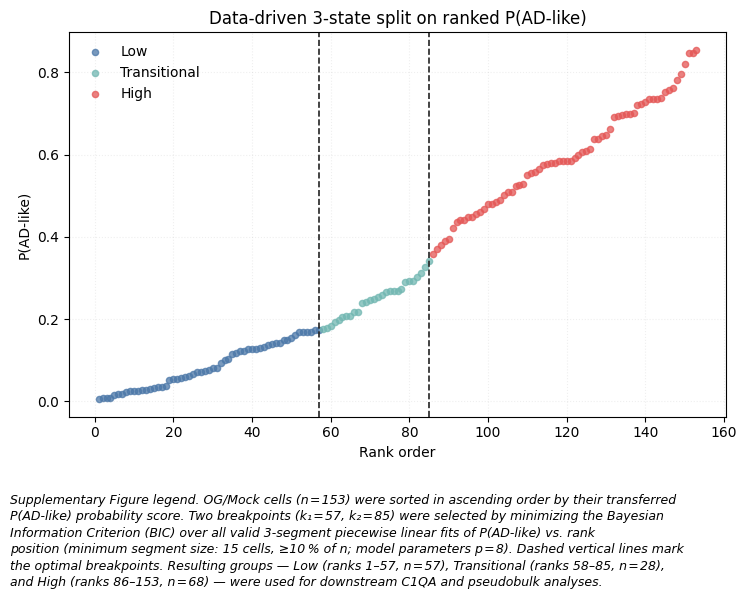

In [10]:
"""
Step 2c-i: Data-driven 3-group split on ranked P(AD-like)
into Low, Transitional, and High states.

Method:
- Sort cells by P(AD-like)
- Fit a 3-segment piecewise-linear model across rank positions
- Choose two breakpoints by BIC (no manual threshold)
- Report group composition and C1QA statistics across groups
- Split C1QA panel by state and condition (Mock vs OG)
"""

import textwrap as _textwrap
from scipy.stats import chi2_contingency, kruskal

required_vars = ["mouse_transfer_df", "mouse_sub"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f"Missing required objects: {missing_vars}. Run Step 2a/2b first.")

tri_df = mouse_transfer_df.copy()
if mouse_sub.n_obs == len(mouse_transfer_df):
    tri_df["cell_barcode"] = mouse_sub.obs_names.astype(str).to_numpy()
else:
    tri_df["cell_barcode"] = pd.NA
    print("Warning: mouse_sub and mouse_transfer_df length mismatch; cell_barcode unavailable for state export.")

tri_df["barcode_key"] = (
    tri_df["cell_barcode"]
    .astype(str)
    .str.strip()
    .str.replace(r"^Mouse_", "", regex=True)
)
tri_df.loc[tri_df["cell_barcode"].isna(), "barcode_key"] = pd.NA

tri_df = tri_df[tri_df["condition"].isin(["OG", "Mock"])].copy()
if tri_df.empty:
    raise RuntimeError("No OG/Mock cells available.")

tri_df = tri_df.sort_values("p_ad_like", ascending=True, kind="mergesort").reset_index(drop=True)
tri_df["rank_order"] = np.arange(1, len(tri_df) + 1)

# Optional C1QA for biological summary
if "C1QA" in mouse_sub.var_names and len(mouse_sub) == len(mouse_transfer_df):
    c1qa_idx = mouse_sub.var_names.get_loc("C1QA")
    c1qa_raw = mouse_sub.layers["counts"][:, c1qa_idx] if "counts" in mouse_sub.layers else mouse_sub.X[:, c1qa_idx]
    c1qa_expr = c1qa_raw.toarray().ravel() if sp.issparse(c1qa_raw) else np.asarray(c1qa_raw).ravel()
    c1qa_map_df = mouse_transfer_df[["p_ad_like", "condition"]].copy()
    c1qa_map_df["C1QA_expr"] = c1qa_expr
    c1qa_map_df = c1qa_map_df.sort_values("p_ad_like", ascending=True, kind="mergesort").reset_index(drop=True)
    tri_df["C1QA_expr"] = c1qa_map_df.loc[tri_df.index, "C1QA_expr"].to_numpy()

x = tri_df["rank_order"].to_numpy(dtype=float)
y = tri_df["p_ad_like"].to_numpy(dtype=float)
n = len(y)

if n < 60:
    raise RuntimeError(f"Need >= 60 cells for stable 3-group segmentation; found n={n}.")

# Ensure each segment has minimum support
min_seg = max(12, int(0.10 * n))

best = None
for k1 in range(min_seg, n - 2 * min_seg + 1):
    for k2 in range(k1 + min_seg, n - min_seg + 1):
        x1, y1 = x[:k1], y[:k1]
        x2, y2 = x[k1:k2], y[k1:k2]
        x3, y3 = x[k2:], y[k2:]

        c1 = np.polyfit(x1, y1, deg=1)
        c2 = np.polyfit(x2, y2, deg=1)
        c3 = np.polyfit(x3, y3, deg=1)

        rss1 = float(np.sum((y1 - np.polyval(c1, x1)) ** 2))
        rss2 = float(np.sum((y2 - np.polyval(c2, x2)) ** 2))
        rss3 = float(np.sum((y3 - np.polyval(c3, x3)) ** 2))
        rss = max(rss1 + rss2 + rss3, 1e-12)

        # Parameters: 3 segments * (slope+intercept)=6 plus 2 breakpoints = 8
        p = 8
        bic = n * np.log(rss / n) + p * np.log(n)

        rec = {
            "k1": int(k1),
            "k2": int(k2),
            "bic": float(bic),
            "rss": float(rss),
            "slope_low": float(c1[0]),
            "slope_transitional": float(c2[0]),
            "slope_high": float(c3[0]),
        }
        if best is None or rec["bic"] < best["bic"]:
            best = rec

if best is None:
    raise RuntimeError("Failed to identify 3-group breakpoints.")

k1_star, k2_star = best["k1"], best["k2"]
tri_df["prob_state_3"] = "Transitional"
tri_df.loc[tri_df["rank_order"] <= k1_star, "prob_state_3"] = "Low"
tri_df.loc[tri_df["rank_order"] > k2_star, "prob_state_3"] = "High"
tri_df["prob_state_3"] = pd.Categorical(tri_df["prob_state_3"], categories=["Low", "Transitional", "High"], ordered=True)

# Persist a compact state map for reuse in export/import bridge cells.
mouse_transfer_prob_state3_df = tri_df[
    ["cell_barcode", "barcode_key", "condition", "p_ad_like", "rank_order", "prob_state_3"]
].copy()

group_summary = (
    tri_df.groupby("prob_state_3", observed=True)
    .agg(
        n_cells=("p_ad_like", "size"),
        p_ad_like_min=("p_ad_like", "min"),
        p_ad_like_median=("p_ad_like", "median"),
        p_ad_like_max=("p_ad_like", "max"),
    )
    .reset_index()
)

cond_table = pd.crosstab(tri_df["prob_state_3"], tri_df["condition"])
chi2_stat, chi2_p, _, _ = chi2_contingency(cond_table)

print("=" * 88)
print("Step 2c-iii: Data-driven 3-state probability split")
print("=" * 88)
print(f"Total OG/Mock cells: {n}")
print(f"Breakpoints: k1={k1_star}, k2={k2_star}")
print("\nSegment slopes:")
print(f"  Low slope:          {best['slope_low']:.6f}")
print(f"  Transitional slope: {best['slope_transitional']:.6f}")
print(f"  High slope:         {best['slope_high']:.6f}")
print("\nGroup summary:")
print(group_summary.to_string(index=False, float_format=lambda z: f"{z:.4g}"))
print("\nCondition composition by group:")
print(cond_table.to_string())
print(f"Chi-square test (group x condition): p={chi2_p:.6g}")

state_cond_test_df = pd.DataFrame()
if "C1QA_expr" in tri_df.columns:
    c1qa_summary = (
        tri_df.groupby("prob_state_3", observed=True)["C1QA_expr"]
        .agg(["count", "mean", "median", "std"])
        .reset_index()
    )
    print("\nC1QA summary by 3-state group:")
    print(c1qa_summary.to_string(index=False, float_format=lambda z: f"{z:.4g}"))

    vals_low = tri_df.loc[tri_df["prob_state_3"] == "Low", "C1QA_expr"].to_numpy()
    vals_trn = tri_df.loc[tri_df["prob_state_3"] == "Transitional", "C1QA_expr"].to_numpy()
    vals_high = tri_df.loc[tri_df["prob_state_3"] == "High", "C1QA_expr"].to_numpy()
    kw = kruskal(vals_low, vals_trn, vals_high, nan_policy="omit")
    print(f"Kruskal-Wallis across Low/Transitional/High: p={float(kw.pvalue):.6g}")

    pair_specs = [
        ("Low", "Transitional", vals_low, vals_trn),
        ("Low", "High", vals_low, vals_high),
        ("Transitional", "High", vals_trn, vals_high),
    ]
    pair_rows = []
    for a, b, va, vb in pair_specs:
        tt = stats.ttest_ind(va, vb, equal_var=False, nan_policy="omit")
        pair_rows.append(
            {
                "comparison": f"{a} vs {b}",
                "delta_mean": float(np.nanmean(va) - np.nanmean(vb)),
                "p_value": float(tt.pvalue),
            }
        )
    pair_df = pd.DataFrame(pair_rows)
    _, padj, _, _ = multipletests(pair_df["p_value"].to_numpy(), method="fdr_bh")
    pair_df["p_adj_bh"] = padj
    pair_df["sig_fdr_05"] = pair_df["p_adj_bh"] < 0.05
    print("\nPairwise C1QA tests (Welch + BH):")
    print(pair_df.to_string(index=False, float_format=lambda z: f"{z:.4g}"))

    # New: within-state OG vs Mock tests (the requested group effect view)
    state_cond_rows = []
    for state in ["Low", "Transitional", "High"]:
        sub = tri_df[tri_df["prob_state_3"] == state]
        v_mock = sub.loc[sub["condition"] == "Mock", "C1QA_expr"].to_numpy()
        v_og = sub.loc[sub["condition"] == "OG", "C1QA_expr"].to_numpy()
        if len(v_mock) >= 3 and len(v_og) >= 3:
            tt_state = stats.ttest_ind(v_og, v_mock, equal_var=False, nan_policy="omit")
            p_state = float(tt_state.pvalue)
        else:
            p_state = np.nan
        state_cond_rows.append(
            {
                "state": state,
                "n_mock": int(len(v_mock)),
                "n_og": int(len(v_og)),
                "mean_mock": float(np.nanmean(v_mock)) if len(v_mock) else np.nan,
                "mean_og": float(np.nanmean(v_og)) if len(v_og) else np.nan,
                "delta_og_minus_mock": float(np.nanmean(v_og) - np.nanmean(v_mock)) if len(v_mock) and len(v_og) else np.nan,
                "p_value": p_state,
            }
        )

    state_cond_test_df = pd.DataFrame(state_cond_rows)
    valid_state = state_cond_test_df["p_value"].notna()
    if valid_state.any():
        _, state_padj, _, _ = multipletests(state_cond_test_df.loc[valid_state, "p_value"], method="fdr_bh")
        state_cond_test_df["p_adj_bh"] = np.nan
        state_cond_test_df.loc[valid_state, "p_adj_bh"] = state_padj
    else:
        state_cond_test_df["p_adj_bh"] = np.nan
    state_cond_test_df["sig_fdr_05"] = state_cond_test_df["p_adj_bh"] < 0.05

    print("\nWithin-state OG vs Mock C1QA (Welch + BH):")
    print(state_cond_test_df.to_string(index=False, float_format=lambda z: f"{z:.4g}"))

# Visualization — left panel only
state_colors = {"Low": "#4C78A8", "Transitional": "#72B7B2", "High": "#E45756"}

fig, ax = plt.subplots(1, 1, figsize=(7.5, 6.0))

for state in ["Low", "Transitional", "High"]:
    sub = tri_df[tri_df["prob_state_3"] == state]
    ax.scatter(sub["rank_order"], sub["p_ad_like"], s=20, alpha=0.75, color=state_colors[state], label=state)
ax.axvline(k1_star, color="#222222", linestyle="--", linewidth=1.2)
ax.axvline(k2_star, color="#222222", linestyle="--", linewidth=1.2)
ax.set_title("Data-driven 3-state split on ranked P(AD-like)")
ax.set_xlabel("Rank order")
ax.set_ylabel("P(AD-like)")
ax.grid(alpha=0.2, linestyle=":")
ax.legend(frameon=False)

figure_legend = _textwrap.fill(
    f"Supplementary Figure legend. OG/Mock cells (n\u200a=\u200a{n}) were sorted in ascending order by their transferred "
    f"P(AD-like) probability score. Two breakpoints (k\u2081\u200a=\u200a{k1_star}, k\u2082\u200a=\u200a{k2_star}) were "
    f"selected by minimizing the Bayesian Information Criterion (BIC) over all valid 3-segment "
    f"piecewise linear fits of P(AD-like) vs. rank position (minimum segment size: {min_seg} cells, "
    f"\u226510\u202f% of n; model parameters p\u200a=\u200a8). Dashed vertical lines mark the optimal "
    f"breakpoints. Resulting groups \u2014 Low (ranks 1\u2013{k1_star}, n\u200a=\u200a{k1_star}), "
    f"Transitional (ranks {k1_star + 1}\u2013{k2_star}, n\u200a=\u200a{k2_star - k1_star}), and "
    f"High (ranks {k2_star + 1}\u2013{n}, n\u200a=\u200a{n - k2_star}) \u2014 were used for downstream "
    f"C1QA and pseudobulk analyses.",
    width=105,
)
fig.text(0.01, 0.01, figure_legend, ha="left", va="bottom", fontsize=9, style="italic", linespacing=1.35)

plt.tight_layout(rect=[0, 0.20, 1, 1])
plt.show()

# Save the figure as SVG in the 'figure' folder
fig.savefig(RESULTS_PLOTS_DIR / "Probability_3-group_Split_nb06.svg", format="svg", bbox_inches="tight")


### 2c-ii: Visualization of groups by C1qa

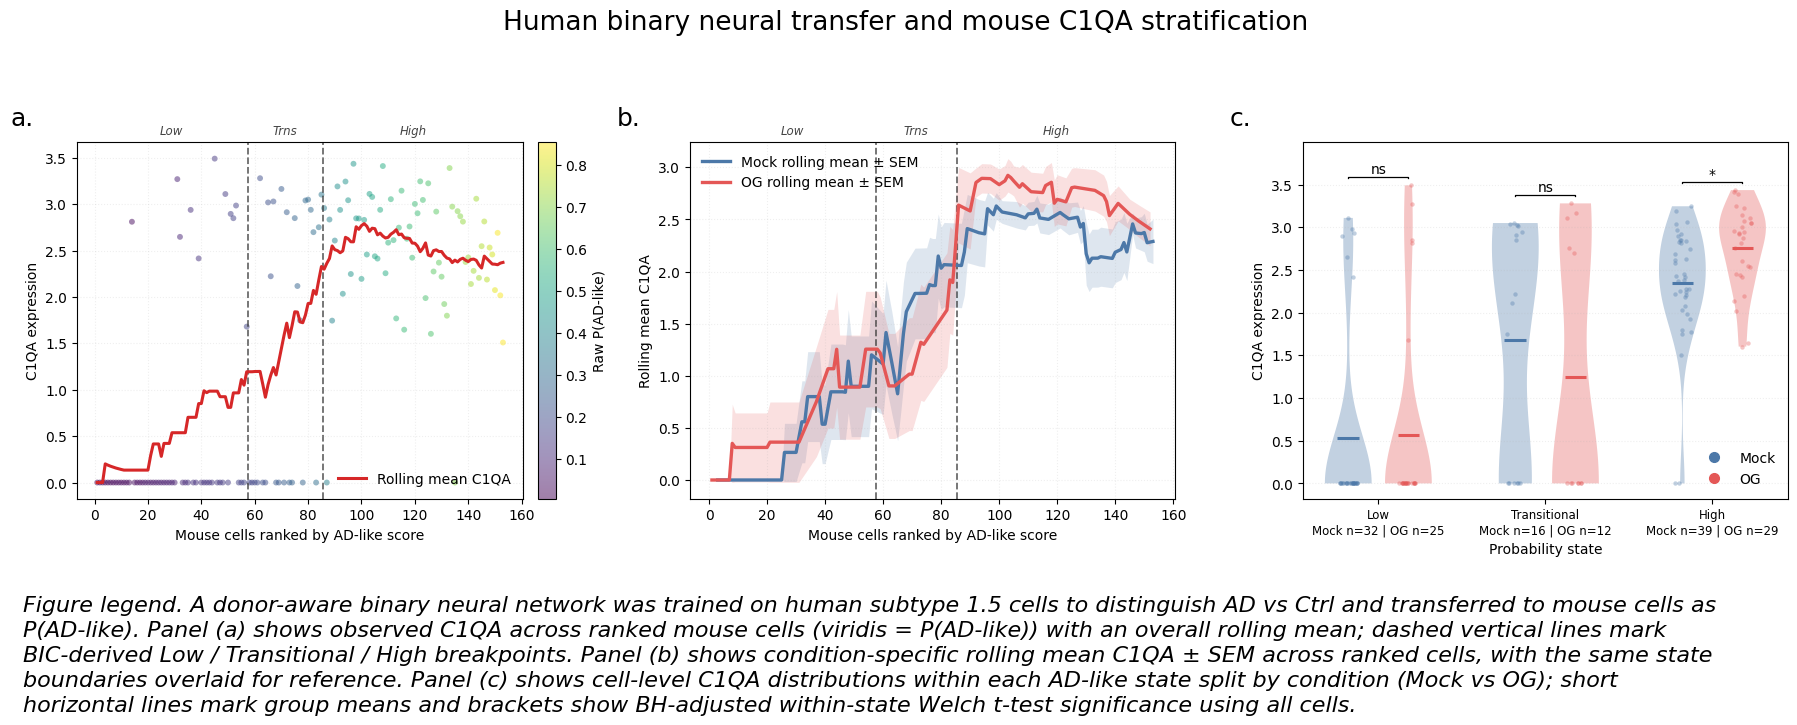

Panel C statistical summary (within-state OG vs Mock, all cells)
       state  n_mock  n_og  delta_og_minus_mock  p_value  p_adj_bh  sig_fdr_05
         Low      32    25              0.03306   0.9155    0.9155       False
Transitional      16    12              -0.4333   0.4536    0.6804       False
        High      39    29               0.4153 0.005357   0.01607        True

Save path (write commented): /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/Plots/mouse_RollingC1qaExpression_nn_probability_transfer_nb06.svg


In [11]:
"""Step 2c-ii: Visualize ranked C1QA trends with Low/Transitional/High boundaries.

Panels:
  a. C1QA expression across ranked mouse cells (viridis = P(AD-like), overall rolling mean).
  b. Rolling C1QA by condition (OG vs Mock) across ranked cells.
  c. Cell-level C1QA within each AD-like state, split by condition (OG vs Mock).
"""

import textwrap as _textwrap

# ── Dependency check ────────────────────────────────────────────────────────
required_vars = ["mouse_transfer_df", "mouse_sub", "tri_df", "k1_star", "k2_star"]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f"Missing: {missing_vars}. Run Step 2c-i first.")

if "C1QA" not in mouse_sub.var_names:
    raise RuntimeError("C1QA not found in mouse_sub.var_names")
c1qa_idx = mouse_sub.var_names.get_loc("C1QA")
c1qa_raw = (
    mouse_sub.layers["counts"][:, c1qa_idx]
    if "counts" in mouse_sub.layers
    else mouse_sub.X[:, c1qa_idx]
)
mouse_c1qa = (
    c1qa_raw.toarray().ravel() if sp.issparse(c1qa_raw) else np.asarray(c1qa_raw).ravel()
)

plot_df = mouse_transfer_df.copy()
plot_df["C1QA_expr"] = mouse_c1qa
plot_df = plot_df.sort_values("p_ad_like", ascending=True, kind="mergesort").reset_index(drop=True)
plot_df["rank_order"] = np.arange(1, len(plot_df) + 1)
plot_df = plot_df[plot_df["condition"].isin(["OG", "Mock"])].copy()
if plot_df.empty:
    raise RuntimeError("No OG/Mock cells available after filtering.")

roll_window = max(21, len(plot_df) // 20)

# Ensure tri_df carries C1QA for the state-level panel.
if "C1QA_expr" not in tri_df.columns:
    c1qa_map_df = mouse_transfer_df[["p_ad_like", "condition"]].copy()
    c1qa_map_df["C1QA_expr"] = mouse_c1qa
    c1qa_map_df = c1qa_map_df.sort_values("p_ad_like", ascending=True, kind="mergesort").reset_index(drop=True)
    tri_df = tri_df.copy()
    tri_df["C1QA_expr"] = c1qa_map_df.loc[tri_df.index, "C1QA_expr"].to_numpy()

# ── Helpers ─────────────────────────────────────────────────────────────────
_vline_kw = {"color": "#333333", "linestyle": "--", "linewidth": 1.3, "alpha": 0.72, "zorder": 1}
_n_plt = len(plot_df)
_rng = np.random.default_rng(42)


def _add_state_bands(ax):
    ax.axvline(k1_star + 0.5, **_vline_kw)
    ax.axvline(k2_star + 0.5, **_vline_kw)
    tr = ax.get_xaxis_transform()
    for lbl, xs, xe in [
        ("Low", 0.5, k1_star),
        ("Trns", k1_star + 0.5, k2_star),
        ("High", k2_star + 0.5, _n_plt + 0.5),
    ]:
        ax.text(
            (xs + xe) / 2,
            1.015,
            lbl,
            ha="center",
            va="bottom",
            fontsize=8.5,
            color="#444444",
            style="italic",
            transform=tr,
            clip_on=False,
        )


def _stars(p_value):
    if not np.isfinite(p_value):
        return "ns"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"


fig, axes = plt.subplots(
    1, 3, figsize=(18, 7.2),
    gridspec_kw={"width_ratios": [1.0, 1.0, 1.0]},
)
panel_labels = ["a.", "b.", "c."]

# ── Panel A: ranked C1QA ────────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(
    plot_df["rank_order"],
    plot_df["C1QA_expr"],
    c=plot_df["p_ad_like"],
    cmap="viridis",
    s=18,
    alpha=0.50,
    linewidths=0,
)
roll_all = pd.Series(plot_df["C1QA_expr"]).rolling(roll_window, center=True, min_periods=7).mean()
ax.plot(plot_df["rank_order"], roll_all, color="#d62728", linewidth=2.2, label="Rolling mean C1QA")
#ax.set_title("C1QA across ranked mouse cells")
ax.set_xlabel("Mouse cells ranked by AD-like score")
ax.set_ylabel("C1QA expression")
ax.grid(alpha=0.2, linestyle=":")
cb = fig.colorbar(sc, ax=ax, fraction=0.05, pad=0.03)
cb.set_label("Raw P(AD-like)")
ax.legend(frameon=False)
ax.annotate(panel_labels[0], xy=(-0.15, 1.10), xycoords="axes fraction", fontsize=18, ha="left", va="top")
_add_state_bands(ax)

# ── Panel B: rolling C1QA by condition over rank ────────────────────────────
ax = axes[1]
for cond, color in [("Mock", "#4C78A8"), ("OG", "#E45756")]:
    cond_sub = plot_df[plot_df["condition"] == cond].copy()
    cond_window = max(9, len(cond_sub) // 8)
    cond_roll_mean = cond_sub["C1QA_expr"].rolling(cond_window, center=True, min_periods=3).mean()
    cond_roll_sem = cond_sub["C1QA_expr"].rolling(cond_window, center=True, min_periods=3).sem()
    lower = (cond_roll_mean - cond_roll_sem).to_numpy()
    upper = (cond_roll_mean + cond_roll_sem).to_numpy()
    xvals = cond_sub["rank_order"].to_numpy()
    yvals = cond_roll_mean.to_numpy()
    valid = np.isfinite(xvals) & np.isfinite(yvals) & np.isfinite(lower) & np.isfinite(upper)
    if valid.any():
        ax.fill_between(xvals[valid], lower[valid], upper[valid], color=color, alpha=0.18, linewidth=0)
    ax.plot(
        cond_sub["rank_order"],
        cond_roll_mean,
        linewidth=2.4,
        color=color,
        label=f"{cond} rolling mean ± SEM",
    )

#ax.set_title("Rolling C1QA by condition over rank")
ax.set_xlabel("Mouse cells ranked by AD-like score")
ax.set_ylabel("Rolling mean C1QA")
ax.grid(alpha=0.2, linestyle=":")
ax.legend(frameon=False, loc="upper left")
ax.annotate(panel_labels[1], xy=(-0.15, 1.10), xycoords="axes fraction", fontsize=18, ha="left", va="top")
_add_state_bands(ax)

# ── Panel C: within-state OG vs Mock, all cells ─────────────────────────────
ax = axes[2]
state_order = ["Low", "Transitional", "High"]
cond_order = ["Mock", "OG"]
cond_colors = {"Mock": "#4C78A8", "OG": "#E45756"}
base_pos = {"Low": 0, "Transitional": 1, "High": 2}
offsets = {"Mock": -0.18, "OG": 0.18}
summary_halfwidth = 0.065

state_cond_rows = []
for state in state_order:
    for cond in cond_order:
        vals = tri_df.loc[
            (tri_df["prob_state_3"] == state) & (tri_df["condition"] == cond),
            "C1QA_expr",
        ].to_numpy()
        xpos = base_pos[state] + offsets[cond]
        if len(vals):
            vp = ax.violinplot(vals, positions=[xpos], widths=0.28, showmedians=False, showextrema=False)
            for body in vp["bodies"]:
                body.set_facecolor(cond_colors[cond])
                body.set_alpha(0.34)
                body.set_edgecolor("none")
            jit = _rng.uniform(-0.055, 0.055, size=len(vals))
            ax.scatter(
                np.full(len(vals), xpos) + jit,
                vals,
                s=10,
                alpha=0.35,
                color=cond_colors[cond],
                linewidths=0,
                zorder=3,
            )
            summary_y = float(np.nanmean(vals))
            ax.hlines(
                y=summary_y,
                xmin=xpos - summary_halfwidth,
                xmax=xpos + summary_halfwidth,
                colors=cond_colors[cond],
                linewidth=2.2,
                zorder=5,
            )

    mock_vals = tri_df.loc[
        (tri_df["prob_state_3"] == state) & (tri_df["condition"] == "Mock"),
        "C1QA_expr",
    ].to_numpy()
    og_vals = tri_df.loc[
        (tri_df["prob_state_3"] == state) & (tri_df["condition"] == "OG"),
        "C1QA_expr",
    ].to_numpy()
    raw_p = (
        float(stats.ttest_ind(og_vals, mock_vals, equal_var=False, nan_policy="omit").pvalue)
        if len(mock_vals) >= 3 and len(og_vals) >= 3
        else np.nan
    )
    state_cond_rows.append(
        {
            "state": state,
            "n_mock": int(len(mock_vals)),
            "n_og": int(len(og_vals)),
            "mean_mock": float(np.nanmean(mock_vals)) if len(mock_vals) else np.nan,
            "mean_og": float(np.nanmean(og_vals)) if len(og_vals) else np.nan,
            "delta_og_minus_mock": float(np.nanmean(og_vals) - np.nanmean(mock_vals)) if len(mock_vals) and len(og_vals) else np.nan,
            "p_value": raw_p,
        }
    )

state_cond_test_df = pd.DataFrame(state_cond_rows)
valid_state = state_cond_test_df["p_value"].notna()
if valid_state.any():
    _, state_padj, _, _ = multipletests(state_cond_test_df.loc[valid_state, "p_value"], method="fdr_bh")
    state_cond_test_df["p_adj_bh"] = np.nan
    state_cond_test_df.loc[valid_state, "p_adj_bh"] = state_padj
else:
    state_cond_test_df["p_adj_bh"] = np.nan
state_cond_test_df["sig_fdr_05"] = state_cond_test_df["p_adj_bh"] < 0.05

all_vals_c = tri_df["C1QA_expr"].to_numpy()
ymax_c = float(np.nanmax(all_vals_c))
ymin_c = float(np.nanmin(all_vals_c))
ystep_c = max((ymax_c - ymin_c) * 0.08, ymax_c * 0.08, 0.05)
cap_c = ystep_c * 0.05
for _, row in state_cond_test_df.iterrows():
    xc = base_pos[row["state"]]
    x1 = xc + offsets["Mock"]
    x2 = xc + offsets["OG"]
    state_vals = tri_df.loc[tri_df["prob_state_3"] == row["state"], "C1QA_expr"].to_numpy()
    h = float(np.nanmax(state_vals)) + ystep_c * 0.35
    ax.plot([x1, x1, x2, x2], [h - cap_c, h, h, h - cap_c], color="black", linewidth=0.9)
    ax.text((x1 + x2) / 2, h + cap_c * 0.7, _stars(row["p_adj_bh"]), ha="center", va="bottom", fontsize=10)

ax.set_ylim(top=ymax_c + ystep_c * 1.8)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(
    [
        f"Low\nMock n={state_cond_test_df.loc[state_cond_test_df['state'] == 'Low', 'n_mock'].iloc[0]} | OG n={state_cond_test_df.loc[state_cond_test_df['state'] == 'Low', 'n_og'].iloc[0]}",
        f"Transitional\nMock n={state_cond_test_df.loc[state_cond_test_df['state'] == 'Transitional', 'n_mock'].iloc[0]} | OG n={state_cond_test_df.loc[state_cond_test_df['state'] == 'Transitional', 'n_og'].iloc[0]}",
        f"High\nMock n={state_cond_test_df.loc[state_cond_test_df['state'] == 'High', 'n_mock'].iloc[0]} | OG n={state_cond_test_df.loc[state_cond_test_df['state'] == 'High', 'n_og'].iloc[0]}",
    ],
    fontsize=8.5,
)
# ax.set_title("C1QA within AD-like states by condition")
ax.set_xlabel("Probability state")
ax.set_ylabel("C1QA expression")
ax.grid(alpha=0.2, linestyle=":", axis="y")
ax.annotate(panel_labels[2], xy=(-0.15, 1.10), xycoords="axes fraction", fontsize=18, ha="left", va="top")
legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=cond_colors[c], markeredgecolor=cond_colors[c], markersize=7, label=c)
    for c in cond_order
]
ax.legend(handles=legend_handles, frameon=False, loc="lower right")

fig.suptitle("Human binary neural transfer and mouse C1QA stratification", y=0.98, fontsize=19)
legend = _textwrap.fill(
    "Figure legend. A donor-aware binary neural network was trained on human subtype 1.5 cells to distinguish AD vs Ctrl and transferred to mouse cells as P(AD-like). "
    "Panel (a) shows observed C1QA across ranked mouse cells (viridis = P(AD-like)) with an overall rolling mean; dashed vertical lines mark BIC-derived Low / Transitional / High breakpoints. "
    "Panel (b) shows condition-specific rolling mean C1QA ± SEM across ranked cells, with the same state boundaries overlaid for reference. "
    "Panel (c) shows cell-level C1QA distributions within each AD-like state split by condition (Mock vs OG); short horizontal lines mark group means and brackets show BH-adjusted within-state Welch t-test significance using all cells.",
    width=150,
)
fig.text(0.01, -0.0, legend, ha="left", va="bottom", fontsize=16, style="italic", linespacing=1.3)

plt.tight_layout(rect=[0, 0.20, 1, 0.95])
plt.show()

print("=" * 80)
print("Panel C statistical summary (within-state OG vs Mock, all cells)")
print("=" * 80)
print(
    state_cond_test_df[
        ["state", "n_mock", "n_og", "delta_og_minus_mock", "p_value", "p_adj_bh", "sig_fdr_05"]
    ].to_string(index=False, float_format=lambda z: f"{z:.4g}")
)

analysis_root_path = Path(ANALYSIS_ROOT) if isinstance(ANALYSIS_ROOT, str) else ANALYSIS_ROOT
fig_path = analysis_root_path / "Results" / "Plots" / "mouse_RollingC1qaExpression_nn_probability_transfer_nb06.svg"
print(f"\nSave path (write commented): {fig_path}")
fig.savefig(fig_path, format="svg", bbox_inches="tight", dpi=300)


## Step 2d: Export Probabilities and Model Artifacts

Save mouse disease-probability outputs and trained model artifacts for reuse in downstream analyses.

In [12]:
"""
Step 2d-i: Export barcode-level probabilities and model artifacts.
"""

from datetime import datetime
import json
import joblib

required_objs = [
    "mouse_transfer_df",
    "mouse_sub",
    "final_nn_model",
    "final_scaler",
    "stable_genes",
]
missing = [k for k in required_objs if k not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects from Step 2a/2b: {missing}")

analysis_root_path = Path(ANALYSIS_ROOT) if isinstance(ANALYSIS_ROOT, str) else ANALYSIS_ROOT
microglia_dir = analysis_root_path / "Microglia_analysis"
model_dir = microglia_dir / "model"
microglia_dir.mkdir(parents=True, exist_ok=True)
model_dir.mkdir(parents=True, exist_ok=True)

# Barcode-level probability table for downstream use.
if mouse_sub.n_obs != len(mouse_transfer_df):
    raise RuntimeError(
        "mouse_sub and mouse_transfer_df row counts differ; rerun Step 2a/2b before export."
    )

prob_export_df = mouse_transfer_df.copy()
prob_export_df.insert(0, "cell_barcode", mouse_sub.obs_names.astype(str).to_numpy())
prob_export_df["barcode_key"] = (
    prob_export_df["cell_barcode"]
    .astype(str)
    .str.strip()
    .str.replace(r"^Mouse_", "", regex=True)
)

# Add 3-state labels from Step 2c when available (preferred: barcode-key merge).
if "tri_df" in globals() and "prob_state_3" in tri_df.columns:
    tri_state_df = tri_df.copy()
    if "barcode_key" not in tri_state_df.columns and "cell_barcode" in tri_state_df.columns:
        tri_state_df["barcode_key"] = (
            tri_state_df["cell_barcode"]
            .astype(str)
            .str.strip()
            .str.replace(r"^Mouse_", "", regex=True)
        )
    merge_cols = ["barcode_key", "prob_state_3"]
    if "rank_order" in tri_state_df.columns:
        merge_cols.append("rank_order")
    tri_state_df = tri_state_df[merge_cols].drop_duplicates(subset=["barcode_key"], keep="first")
    tri_state_df = tri_state_df.rename(columns={"rank_order": "prob_state_rank_order"})
    prob_export_df = prob_export_df.drop(columns=["prob_state_3", "prob_state_rank_order"], errors="ignore")
    prob_export_df = prob_export_df.merge(tri_state_df, on="barcode_key", how="left")

    n_state = int(prob_export_df["prob_state_3"].notna().sum())
    print(f"Added prob_state_3 to export for {n_state}/{len(prob_export_df)} rows.")
else:
    print("Step 2c state labels not found; exporting probabilities without prob_state_3.")

prob_export_path = microglia_dir / "mouse_ad_like_probabilities_with_barcodes_nb06.csv"
prob_export_df.to_csv(prob_export_path, index=False)

# Persist model package needed to score new data consistently.
model_bundle = {
    "final_nn_model": final_nn_model,
    "final_scaler": final_scaler,
    "stable_genes": stable_genes,
    "subtype_target": SUBTYPE_TARGET,
    "human_label_col": HUMAN_LABEL_COL,
    "mouse_label_col": MOUSE_LABEL_COL,
    "random_state": RANDOM_STATE,
    "normalization": "library_size_to_1e4_then_log1p",
}
model_bundle_path = model_dir / "human_to_mouse_adlike_mlp_model_bundle_nb06.joblib"
joblib.dump(model_bundle, model_bundle_path)

cv_metrics = {}
if "cv_df" in globals() and len(cv_df) > 0:
    cv_metrics = {
        "n_folds": int(len(cv_df)),
        "auc_mean": float(cv_df["auc"].mean()),
        "ap_mean": float(cv_df["ap"].mean()),
        "brier_mean": float(cv_df["brier"].mean()),
    }

model_description = {
    "model_name": "Human-to-mouse AD-like transfer MLP",
    "created_utc": datetime.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
    "notebook": "06_reduild.ipynb",
    "task": "Binary AD-vs-Ctrl in human subtype 1.5; transfer P(AD-like) to mouse subtype 1.5",
    "features": {
        "n_stable_genes": int(len(stable_genes)),
        "stable_genes_preview": stable_genes[:30],
        "normalization": "Per-cell libsize scaling to 1e4 then log1p",
    },
    "training": {
        "model_class": "sklearn.neural_network.MLPClassifier",
        "final_model_params": final_nn_model.get_params(),
        "cv_summary": cv_metrics,
    },
    "artifacts": {
        "probability_table": str(prob_export_path),
        "model_bundle": str(model_bundle_path),
    },
    "outputs_columns": list(prob_export_df.columns),
}

model_desc_path = model_dir / "human_to_mouse_adlike_mlp_model_description_nb06.json"
with open(model_desc_path, "w", encoding="utf-8") as f:
    json.dump(model_description, f, indent=2)

print("=" * 80)
print("Step 2d export complete")
print("=" * 80)
print(f"Saved probability table: {prob_export_path}")
print(f"Saved model bundle:      {model_bundle_path}")
print(f"Saved model description: {model_desc_path}")
print(f"Rows exported: {len(prob_export_df)}")
print("=" * 80)

Added prob_state_3 to export for 153/153 rows.
Step 2d export complete
Saved probability table: /media/drive_c/Project_Brain_snRNAseq/Analysis/Microglia_analysis/mouse_ad_like_probabilities_with_barcodes_nb06.csv
Saved model bundle:      /media/drive_c/Project_Brain_snRNAseq/Analysis/Microglia_analysis/model/human_to_mouse_adlike_mlp_model_bundle_nb06.joblib
Saved model description: /media/drive_c/Project_Brain_snRNAseq/Analysis/Microglia_analysis/model/human_to_mouse_adlike_mlp_model_description_nb06.json
Rows exported: 153


# Step 3: Gene Dynamics Across Ranked Mouse Cells

Assess transcriptome-wide expression changes along the continuous transferred `P(AD-like)` ranking using the humanized mouse microglia AnnData from Notebook 02 (`mouse_microglia_humanized_nb02.h5ad`).

This object preserves both name spaces for cross-species interpretation:

- `var_names`: human gene symbols
- `var['mouse_gene']`: original mouse symbols

Workflow in this section:
- Read the Step 2 probability export with `cell_barcode` values.
- Load humanized microglia AnnData from Notebook 02 and filter to matched barcodes.
- Transfer probability columns into AnnData `.obs`.
- Run gene-level trend statistics and module-like trajectory analysis on the matched matrix.

In [13]:
"""
Step 3a: Reload humanized microglia AnnData and attach transferred probabilities by barcode.
"""

import anndata as ad

analysis_root_path = Path(ANALYSIS_ROOT) if isinstance(ANALYSIS_ROOT, str) else ANALYSIS_ROOT
prob_export_path = analysis_root_path / "Microglia_analysis" / "mouse_ad_like_probabilities_with_barcodes_nb06.csv"
microglia_humanized_path = analysis_root_path / "adatas" / "mouse_microglia_humanized_nb02.h5ad"

if not prob_export_path.exists():
    raise FileNotFoundError(
        f"Probability file not found: {prob_export_path}. Run Step 2d first."
    )
if not microglia_humanized_path.exists():
    raise FileNotFoundError(
        f"Humanized microglia AnnData not found: {microglia_humanized_path}."
    )

prob_df = pd.read_csv(prob_export_path)
if "cell_barcode" not in prob_df.columns:
    raise RuntimeError("Expected `cell_barcode` column in exported probability table from Step 2d.")

prob_df["cell_barcode"] = prob_df["cell_barcode"].astype(str).str.strip()
prob_df["barcode_key"] = prob_df["cell_barcode"].str.replace(r"^Mouse_", "", regex=True)
prob_df = prob_df.drop_duplicates(subset=["barcode_key"], keep="first")
prob_df = prob_df.set_index("barcode_key", drop=True)

humanized_micro_adata = ad.read_h5ad(microglia_humanized_path)
humanized_micro_adata.obs_names = humanized_micro_adata.obs_names.astype(str)
adata_barcode_key = pd.Index(humanized_micro_adata.obs_names).str.replace(r"^Mouse_", "", regex=True)

matched_keys = adata_barcode_key.intersection(prob_df.index)
if len(matched_keys) == 0:
    raise RuntimeError(
        "No overlapping barcodes between humanized microglia AnnData and Step 2 probabilities after key normalization."
    )

match_mask = adata_barcode_key.isin(matched_keys)
micro_prob_adata = humanized_micro_adata[match_mask].copy()
micro_prob_adata.obs["barcode_key"] = adata_barcode_key[match_mask].to_numpy()
prob_matched = prob_df.loc[micro_prob_adata.obs["barcode_key"]]

for col in prob_matched.columns:
    if col == "cell_barcode":
        continue
    micro_prob_adata.obs[col] = prob_matched[col].to_numpy()

if "p_ad_like_rank_pct" not in micro_prob_adata.obs.columns:
    raise RuntimeError("`p_ad_like_rank_pct` missing after probability transfer.")

if "prob_state_3" in micro_prob_adata.obs.columns:
    micro_prob_adata.obs["prob_state_3"] = pd.Categorical(
        micro_prob_adata.obs["prob_state_3"],
        categories=["Low", "Transitional", "High"],
        ordered=True,
    )
else:
    print("Warning: `prob_state_3` missing in Step 2d export; rerun Step 2c-i then Step 2d for aligned state analyses.")

# Ensure both naming systems are available for downstream interpretation.
if "human_gene" not in micro_prob_adata.var.columns:
    micro_prob_adata.var["human_gene"] = micro_prob_adata.var_names.astype(str)
if "mouse_gene" not in micro_prob_adata.var.columns:
    micro_prob_adata.var["mouse_gene"] = micro_prob_adata.var_names.astype(str)

# Use log-normalized values when available; otherwise derive from counts/X.
if "log_norm" in micro_prob_adata.layers:
    X_expr = micro_prob_adata.layers["log_norm"]
elif "counts" in micro_prob_adata.layers:
    X_expr = micro_prob_adata.layers["counts"]
    if sp.issparse(X_expr):
        X_expr = X_expr.toarray()
    else:
        X_expr = np.asarray(X_expr)
    lib = np.sum(X_expr, axis=1, keepdims=True)
    lib = np.maximum(lib, 1e-8)
    X_expr = np.log1p((X_expr / lib) * 1e4)
else:
    X_expr = micro_prob_adata.X

if sp.issparse(X_expr):
    X_expr = X_expr.toarray()
else:
    X_expr = np.asarray(X_expr)

print("=" * 80)
print("Step 3a data bridge complete")
print("=" * 80)
print(f"Loaded humanized microglia AnnData: {humanized_micro_adata.shape}")
print(f"Matched barcodes with probabilities: {micro_prob_adata.n_obs}")
if "prob_state_3" in micro_prob_adata.obs.columns:
    state_counts = micro_prob_adata.obs["prob_state_3"].value_counts(dropna=False)
    print("prob_state_3 counts:")
    print(state_counts.to_string())
print(f"Genes retained for Step 3 analysis: {micro_prob_adata.n_vars}")
print(
    "Name columns available in var: "
    f"human_gene={'human_gene' in micro_prob_adata.var.columns}, "
    f"mouse_gene={'mouse_gene' in micro_prob_adata.var.columns}"
)
print("=" * 80)

Step 3a data bridge complete
Loaded humanized microglia AnnData: (280, 14781)
Matched barcodes with probabilities: 153
prob_state_3 counts:
prob_state_3
High            68
Low             57
Transitional    28
Genes retained for Step 3 analysis: 14781
Name columns available in var: human_gene=True, mouse_gene=True


### Step 3b: Gene and Module Trend Analysis

Compute gene-level rank correlations with statistical significance and Benjamini-Hochberg adjusted p-values (`p_adj_bh`), derive module-like trajectories by clustering dynamic gene trends across rank bins, and quantify module significance via module-score association with rank (`module_corr`, `module_corr_p_adj_bh`).

In [14]:
"""
Step 3b setup guard: ensure gene_names exists and matches X_expr width.
"""

if "micro_prob_adata" not in globals():
    raise RuntimeError("micro_prob_adata is missing. Run Step 3a first.")
if "X_expr" not in globals():
    raise RuntimeError("X_expr is missing. Run Step 3a first.")

if "human_gene" in micro_prob_adata.var.columns:
    gene_names = micro_prob_adata.var["human_gene"].astype(str).to_numpy()
else:
    gene_names = micro_prob_adata.var_names.astype(str).to_numpy()

if int(X_expr.shape[1]) != int(len(gene_names)):
    raise RuntimeError(
        f"Gene axis mismatch: X_expr has {X_expr.shape[1]} columns but gene_names has {len(gene_names)} entries."
    )

print(f"Step 3b setup ready: {len(gene_names)} gene names aligned to X_expr.")

Step 3b setup ready: 14781 gene names aligned to X_expr.


In [15]:
"""
Step 3b: Gene trajectory module clustering.
Identifies gene co-expression modules based on expression trajectory shape
across the AD-like probability rank axis.
"""

from sklearn.cluster import KMeans

# --- Rank-correlation trendline for each gene ---
rank_pct = micro_prob_adata.obs["p_ad_like_rank_pct"].to_numpy(dtype=float)
Xz = X_expr
n_cells = len(rank_pct)

corr_with_rank = np.array(
    [
        stats.pearsonr(Xz[:, j], rank_pct)[0] if np.std(Xz[:, j]) > 1e-12 else 0.0
        for j in range(Xz.shape[1])
    ]
)

r = np.clip(corr_with_rank, -0.999999, 0.999999)
df = n_cells - 2
t_stat = r * np.sqrt(df / np.maximum(1.0 - r * r, 1e-12))
p_value = 2.0 * stats.t.sf(np.abs(t_stat), df=df)
_, p_adj_bh, _, _ = multipletests(p_value, alpha=0.05, method="fdr_bh")

gene_trend_df = pd.DataFrame(
    {
        "gene": gene_names,
        "corr_with_rank": corr_with_rank,
        "p_value": p_value,
        "p_adj_bh": p_adj_bh,
    }
)
gene_trend_df["abs_corr"] = gene_trend_df["corr_with_rank"].abs()
gene_trend_df["significant_fdr_05"] = gene_trend_df["p_adj_bh"] < 0.05
gene_trend_df = gene_trend_df.sort_values("corr_with_rank", ascending=False).reset_index(drop=True)

top_n = 20
top_up = gene_trend_df.head(top_n).copy()
top_down = gene_trend_df.tail(top_n).sort_values("corr_with_rank", ascending=True).copy()

n_sig = int(gene_trend_df["significant_fdr_05"].sum())
n_sig_up = int(
    ((gene_trend_df["corr_with_rank"] > 0) & gene_trend_df["significant_fdr_05"]).sum()
)
n_sig_down = int(
    ((gene_trend_df["corr_with_rank"] < 0) & gene_trend_df["significant_fdr_05"]).sum()
)
print(f"\nSignificant genes at FDR < 0.05: {n_sig} (up={n_sig_up}, down={n_sig_down})")

print("\nTop increasing genes across rank (positive corr):")
print(
    top_up[["gene", "corr_with_rank", "p_adj_bh"]].to_string(
        index=False,
        float_format=lambda x: f"{x:.4g}",
    )
)
print("\nTop decreasing genes across rank (negative corr):")
print(
    top_down[["gene", "corr_with_rank", "p_adj_bh"]].to_string(
        index=False,
        float_format=lambda x: f"{x:.4g}",
    )
)

# --- Gene pool size diagnostic: FDR x |r| threshold sweep ---
fdr_thresholds = [0.05, 0.01, 0.001]
r_thresholds = [0.0, 0.10, 0.15, 0.20, 0.30]
abs_r = gene_trend_df["abs_corr"].to_numpy()
p_adj = gene_trend_df["p_adj_bh"].to_numpy()

print("\n--- Gene pool size at FDR × |r| thresholds (for module clustering) ---")
header = f"{'':12s}" + "".join(f"  |r|>={t:.2f}" for t in r_thresholds)
print(header)
for fdr in fdr_thresholds:
    row = f"FDR<{fdr:<8g}"
    for r_min in r_thresholds:
        n = int(((p_adj < fdr) & (abs_r >= r_min)).sum())
        row += f"  {n:>9d}"
    print(row)
print("(using: FDR < 0.05 AND |r| >= 0.30)")

# Gene pool: genes with FDR < 0.05 AND |r| >= 0.30
MODULE_FDR_CUTOFF = 0.05
MODULE_R_CUTOFF = 0.30
fdr_sel_mask = (p_adj_bh < MODULE_FDR_CUTOFF) & (np.abs(corr_with_rank) >= MODULE_R_CUTOFF)
sel_idx = np.where(fdr_sel_mask)[0]
module_gene_pool = len(sel_idx)
print(
    f"Module gene pool (FDR < {MODULE_FDR_CUTOFF}, |r| >= {MODULE_R_CUTOFF}): "
    f"{module_gene_pool} genes"
)

if module_gene_pool < 2:
    raise RuntimeError(
        "Insufficient genes for module clustering after thresholds. "
        "Relax MODULE_R_CUTOFF or inspect upstream data."
    )

sel_genes = [gene_names[i] for i in sel_idx]
sel_X = X_expr[:, sel_idx]

n_bins = min(20, max(8, len(rank_pct) // 100))
bin_idx = np.floor(rank_pct * n_bins).astype(int)
bin_idx = np.clip(bin_idx, 0, n_bins - 1)

traj = np.zeros((module_gene_pool, n_bins), dtype=float)
for b in range(n_bins):
    m = bin_idx == b
    if np.any(m):
        traj[:, b] = sel_X[m].mean(axis=0)
    else:
        traj[:, b] = np.nan

for i in range(traj.shape[0]):
    row = traj[i]
    if np.isnan(row).any():
        good = np.where(~np.isnan(row))[0]
        if len(good) >= 2:
            row[np.isnan(row)] = np.interp(np.where(np.isnan(row))[0], good, row[good])
        elif len(good) == 1:
            row[np.isnan(row)] = row[good[0]]
        else:
            row[:] = 0.0
    traj[i] = row

traj_mean = traj.mean(axis=1, keepdims=True)
traj_std = traj.std(axis=1, keepdims=True)
traj_std = np.where(traj_std < 1e-12, 1e-12, traj_std)
traj_z = (traj - traj_mean) / traj_std

n_modules = min(4, max(2, module_gene_pool // 50))
kmeans = KMeans(n_clusters=n_modules, random_state=RANDOM_STATE, n_init=20)
module_labels = kmeans.fit_predict(traj_z)

module_score_df = micro_prob_adata.obs.copy()
plot_order = np.argsort(module_score_df["p_ad_like_rank_pct"].to_numpy())
module_score_df = module_score_df.iloc[plot_order].reset_index(drop=True)
module_score_df["rank_order"] = np.arange(1, len(module_score_df) + 1)

module_corr_rows = []
for m in range(n_modules):
    members = np.where(module_labels == m)[0]
    if len(members) == 0:
        continue

    module_id = f"M{m + 1}"
    module_genes = [sel_genes[j] for j in members]
    score = Xz[:, sel_idx[members]].mean(axis=1)
    module_score_df[module_id] = score[plot_order]

    if np.std(score) > 1e-12 and np.std(rank_pct) > 1e-12:
        module_corr, module_corr_p = stats.pearsonr(score, rank_pct)
    else:
        module_corr, module_corr_p = 0.0, 1.0

    module_corr_rows.append(
        {
            "module": module_id,
            "module_corr": float(module_corr),
            "module_corr_p": float(module_corr_p),
            "n_genes": int(len(module_genes)),
        }
    )

module_summary_df = pd.DataFrame(module_corr_rows).sort_values("module").reset_index(drop=True)
if not module_summary_df.empty:
    _, module_corr_adj, _, _ = multipletests(
        module_summary_df["module_corr_p"],
        alpha=0.05,
        method="fdr_bh",
    )
    module_summary_df["module_corr_p_adj_bh"] = module_corr_adj
    module_summary_df["module_rank_assoc_sig_fdr_05"] = (
        module_summary_df["module_corr_p_adj_bh"] < 0.05
    )

module_label_map = {f"M{m + 1}": np.where(module_labels == m)[0] for m in range(n_modules)}
module_gene_sets_dict = {
    f"M{m + 1}": [sel_genes[j] for j in np.where(module_labels == m)[0]]
    for m in range(n_modules)
}
module_gene_count_map = {
    row["module"]: int(row["n_genes"]) for _, row in module_summary_df.iterrows()
}

sig_gene_set = set(gene_trend_df.loc[gene_trend_df["significant_fdr_05"], "gene"].astype(str))
module_enrich_rows = []
for m in range(n_modules):
    members = np.where(module_labels == m)[0]
    module_id = f"M{m + 1}"
    module_genes = [sel_genes[j] for j in members]
    n_sig_module = sum(g in sig_gene_set for g in module_genes)
    module_enrich_rows.append(
        {
            "module": module_id,
            "n_genes": len(module_genes),
            "n_sig_fdr05": n_sig_module,
        }
    )
module_enrich_df = pd.DataFrame(module_enrich_rows).sort_values("module")

print("\nModule significance summary:")
print(
    module_summary_df[
        [
            "module",
            "n_genes",
            "module_corr",
            "module_corr_p_adj_bh",
            "module_rank_assoc_sig_fdr_05",
        ]
    ].to_string(index=False, float_format=lambda x: f"{x:.4g}")
)

# Preserve representative genes table for interpretability.
module_summary_rows = []
for m in range(n_modules):
    members = np.where(module_labels == m)[0]
    if len(members) == 0:
        continue

    center = traj_z[members].mean(axis=0)
    module_genes = [sel_genes[j] for j in members]
    dists = ((traj_z[members] - center[None, :]) ** 2).sum(axis=1)
    top_rep_local = np.argsort(dists)[:8]
    top_rep_genes = [module_genes[j] for j in top_rep_local]
    module_summary_rows.append(
        {
            "module": f"M{m + 1}",
            "n_genes": len(module_genes),
            "example_genes": ", ".join(top_rep_genes),
        }
    )

module_examples_df = pd.DataFrame(module_summary_rows).sort_values("module")
print("\nModule representative genes:")
print(module_examples_df.to_string(index=False))


Significant genes at FDR < 0.05: 2405 (up=2284, down=121)

Top increasing genes across rank (positive corr):
    gene  corr_with_rank  p_adj_bh
    VSIR          0.7025 6.775e-20
 IFITM10           0.698 8.604e-20
    LGMN          0.6935 8.706e-20
  TCIRG1          0.6934 8.706e-20
   CSF1R          0.6928 8.706e-20
    CST3          0.6922 8.706e-20
    HEXB          0.6918 8.706e-20
   ELMO1          0.6911 8.706e-20
      QK          0.6882 1.324e-19
   ADAP2          0.6878 1.324e-19
   HPGDS          0.6875 1.324e-19
 UNC93B1          0.6836 2.591e-19
 SERINC3          0.6817 3.483e-19
    CTSS          0.6805 4.075e-19
  TGFBR1           0.677 7.388e-19
  PHYHD1          0.6761 8.163e-19
   ITGB5          0.6758 8.183e-19
  KCTD12          0.6746 9.776e-19
  TBXAS1          0.6741 1.009e-18
ARHGAP45          0.6736 1.045e-18

Top decreasing genes across rank (negative corr):
  gene  corr_with_rank  p_adj_bh
 KALRN         -0.5146 1.058e-09
CAMK2A         -0.4613 1.197e-07
 GRIA

### Step 3c: DGE Overlap and Enrichment on Modules and Correlated Gene

Assess the overlap between DGE and Correlating Genes

Run over-representation analysis (ORA) for:
- module gene sets from Step 3b (module-level interpretation)
- global high-rank and low-rank differential gene lists (axis-level interpretation)

Databases queried: GO BP, KEGG, Reactome, WikiPathways, and Jensen DISEASES.

### Section 3c-i: Correlation-DGE Overlap

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


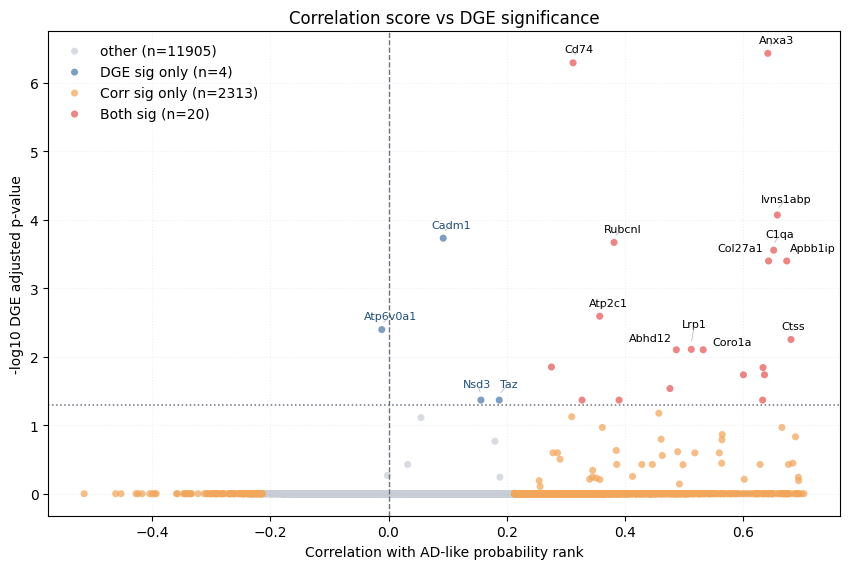

Section 3c-i: visual comparison summary
Genes matched between tables: 14242
DGE-significant genes in matched set: 24
Correlation-significant genes in matched set: 2333
Significant by both: 20

joint_group
other            11905
Corr sig only     2313
Both sig            20
DGE sig only         4


In [16]:
"""
Section 3c-i: Visual comparison of correlation score vs DGE significance.

Compares:
- volcano_df: cluster DGE table
- gene_trend_df: gene-wise correlation table from Step 3b
"""

required = ["volcano_df", "gene_trend_df"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Missing required objects: {missing}")

required_volcano_cols = ["gene", "p_adj", "logFC", "sig"]
missing_volcano = [col for col in required_volcano_cols if col not in volcano_df.columns]
if missing_volcano:
    raise RuntimeError(f"volcano_df missing columns: {missing_volcano}")

required_corr_cols = ["gene", "corr_with_rank", "p_adj_bh", "significant_fdr_05"]
missing_corr = [col for col in required_corr_cols if col not in gene_trend_df.columns]
if missing_corr:
    raise RuntimeError(f"gene_trend_df missing columns: {missing_corr}")

volcano_cmp = volcano_df[["gene", "p_adj", "logFC", "sig"]].copy()
volcano_cmp["gene_key"] = volcano_cmp["gene"].astype(str).str.strip().str.upper()
volcano_cmp["dge_sig"] = volcano_cmp["sig"].astype(str) != "Not significant"
volcano_cmp["neg_log10_dge_padj"] = -np.log10(np.clip(volcano_cmp["p_adj"].to_numpy(dtype=float), 1e-300, None))

corr_cmp = gene_trend_df[["gene", "corr_with_rank", "p_adj_bh", "significant_fdr_05"]].copy()
corr_cmp["gene_key"] = corr_cmp["gene"].astype(str).str.strip().str.upper()
corr_cmp = corr_cmp.rename(columns={"gene": "corr_gene", "significant_fdr_05": "corr_sig"})

compare_df = (
    volcano_cmp.merge(
        corr_cmp[["corr_gene", "gene_key", "corr_with_rank", "p_adj_bh", "corr_sig"]],
        on="gene_key",
        how="inner",
    )
    .drop_duplicates(subset=["gene_key"])
    .reset_index(drop=True)
)

if compare_df.empty:
    raise RuntimeError(
        "No genes matched between volcano_df and gene_trend_df by normalized gene symbol. "
        "This likely indicates a naming/species mismatch."
    )

compare_df["joint_group"] = "other"
compare_df.loc[compare_df["dge_sig"], "joint_group"] = "DGE sig only"
compare_df.loc[compare_df["corr_sig"], "joint_group"] = "Corr sig only"
compare_df.loc[compare_df["dge_sig"] & compare_df["corr_sig"], "joint_group"] = "Both sig"

palette = {
    "other": "#C9CED6",
    "DGE sig only": "#4C78A8",
    "Corr sig only": "#F2A65A",
    "Both sig": "#E45756",
}

try:
    from adjustText import adjust_text
except ImportError:
    adjust_text = None

fig, ax_scatter = plt.subplots(1, 1, figsize=(8.6, 5.8))

for label in ["other", "DGE sig only", "Corr sig only", "Both sig"]:
    sub = compare_df[compare_df["joint_group"] == label]
    if sub.empty:
        continue
    ax_scatter.scatter(
        sub["corr_with_rank"],
        sub["neg_log10_dge_padj"],
        s=26,
        alpha=0.72,
        color=palette[label],
        edgecolor="none",
        label=f"{label} (n={len(sub)})",
    )

ax_scatter.axvline(0, color="#6B7280", linestyle="--", linewidth=1.0)
ax_scatter.axhline(-np.log10(0.05), color="#6B7280", linestyle=":", linewidth=1.1)
ax_scatter.set_xlabel("Correlation with AD-like probability rank")
ax_scatter.set_ylabel("-log10 DGE adjusted p-value")
ax_scatter.set_title("Correlation score vs DGE significance")
ax_scatter.grid(alpha=0.18, linestyle=":")
ax_scatter.legend(frameon=False, loc="upper left")

texts = []

both_sig_df = compare_df[compare_df["joint_group"] == "Both sig"].copy()
if not both_sig_df.empty:
    both_sig_df = both_sig_df.sort_values(["p_adj", "p_adj_bh"], ascending=[True, True]).head(12)
    for _, row in both_sig_df.iterrows():
        texts.append(
            ax_scatter.text(
                row["corr_with_rank"],
                row["neg_log10_dge_padj"] + 0.08,
                str(row["gene"]),
                fontsize=8,
                ha="center",
                va="bottom",
            )
        )

dge_only_df = compare_df[compare_df["joint_group"] == "DGE sig only"].copy()
if not dge_only_df.empty:
    dge_only_df = dge_only_df.sort_values(["p_adj", "neg_log10_dge_padj"], ascending=[True, False])
    for _, row in dge_only_df.iterrows():
        texts.append(
            ax_scatter.text(
                row["corr_with_rank"],
                row["neg_log10_dge_padj"] + 0.08,
                str(row["gene"]),
                fontsize=8,
                ha="center",
                va="bottom",
                color="#1F4E79",
            )
        )

if adjust_text is not None and texts:
    adjust_text(
        texts,
        ax=ax_scatter,
        only_move={"points": "y", "text": "xy"},
        expand_text=(1.05, 1.2),
        expand_points=(1.05, 1.15),
        force_text=(0.2, 0.35),
        force_points=(0.15, 0.25),
        arrowprops={"arrowstyle": "-", "color": "#9CA3AF", "lw": 0.6, "alpha": 0.7},
    )

plt.tight_layout()
plt.show()

print("=" * 96)
print("Section 3c-i: visual comparison summary")
print("=" * 96)
print(f"Genes matched between tables: {len(compare_df)}")
print(f"DGE-significant genes in matched set: {int(compare_df['dge_sig'].sum())}")
print(f"Correlation-significant genes in matched set: {int(compare_df['corr_sig'].sum())}")
print(f"Significant by both: {int((compare_df['dge_sig'] & compare_df['corr_sig']).sum())}")
print()
print(compare_df['joint_group'].value_counts().to_string())

### Section 3c-ii: Module Enrichment Analysis

In [17]:
"""
Step 3c: Run ORA enrichment for module gene sets and global high-vs-low gene lists.
"""

import time

try:
    import gseapy as gp
except ImportError as e:
    raise ImportError(
        "gseapy is required for enrichment analysis. Install it in this environment first."
    ) from e

ENRICH_LIBRARIES = [
    "GO_Biological_Process_2023",
    "KEGG_2021_Human",
    "Reactome_2022",
    "WikiPathways_2024_Human",
    "Jensen_DISEASES",
]
MIN_GENES_FOR_ORA = 5
ENRICHR_MAX_RETRIES = 4
ENRICHR_RETRY_BASE_SECONDS = 2.0
ENRICHR_INTER_REQUEST_SECONDS = 0.4


def run_enrichr_safe(gene_list, libraries, gene_set_name):
    if len(gene_list) < MIN_GENES_FOR_ORA:
        return pd.DataFrame(
            {
                "gene_set_name": [gene_set_name],
                "status": [f"skipped: fewer than {MIN_GENES_FOR_ORA} genes"],
            }
        )

    all_rows = []
    for lib in libraries:
        last_exc = None
        for attempt in range(1, ENRICHR_MAX_RETRIES + 1):
            try:
                enr = gp.enrichr(
                    gene_list=gene_list,
                    gene_sets=[lib],
                    organism="human",
                    outdir=None,
                    no_plot=True,
                )
                df = enr.results.copy()
                if df is None or df.empty:
                    all_rows.append(
                        pd.DataFrame(
                            {
                                "gene_set_name": [gene_set_name],
                                "library": [lib],
                                "status": ["no_hits"],
                            }
                        )
                    )
                else:
                    df["gene_set_name"] = gene_set_name
                    df["library"] = lib
                    df["status"] = "ok"
                    all_rows.append(df)
                break
            except Exception as exc:
                last_exc = exc
                message = str(exc)
                is_rate_limited = "429" in message or "rate limit" in message.lower()
                if is_rate_limited and attempt < ENRICHR_MAX_RETRIES:
                    sleep_seconds = ENRICHR_RETRY_BASE_SECONDS * attempt
                    print(
                        f"Retrying Enrichr for gene_set={gene_set_name}, library={lib} "
                        f"after rate limit ({attempt}/{ENRICHR_MAX_RETRIES - 1}); "
                        f"sleep={sleep_seconds:.1f}s"
                    )
                    time.sleep(sleep_seconds)
                    continue

                all_rows.append(
                    pd.DataFrame(
                        {
                            "gene_set_name": [gene_set_name],
                            "library": [lib],
                            "status": [f"error: {type(exc).__name__}: {exc}"],
                        }
                    )
                )
                break
        time.sleep(ENRICHR_INTER_REQUEST_SECONDS)

    if not all_rows:
        return pd.DataFrame(
            {
                "gene_set_name": [gene_set_name],
                "status": ["no_results"],
            }
        )

    return pd.concat(all_rows, ignore_index=True, sort=False)


# --- Build module gene lists from Step 3b outputs ---
module_gene_sets = {}
for m in range(n_modules):
    members = np.where(module_labels == m)[0]
    module_id = f"M{m + 1}"
    genes = [sel_genes[j] for j in members]
    if len(genes) >= MIN_GENES_FOR_ORA:
        module_gene_sets[module_id] = sorted(set(map(str, genes)))

# --- Build global high-vs-low differential lists (aligned with Step 3d volcano logic) ---
rank_vals = micro_prob_adata.obs["p_ad_like_rank_pct"].to_numpy(dtype=float)
low_cut = np.quantile(rank_vals, 0.25)
high_cut = np.quantile(rank_vals, 0.75)
low_mask = rank_vals <= low_cut
high_mask = rank_vals >= high_cut

X_low = X_expr[low_mask, :]
X_high = X_expr[high_mask, :]
delta_expr = X_high.mean(axis=0) - X_low.mean(axis=0)
tt = stats.ttest_ind(X_high, X_low, axis=0, equal_var=False, nan_policy="omit")
p_group = np.asarray(tt.pvalue, dtype=float)
p_group = np.nan_to_num(p_group, nan=1.0, posinf=1.0, neginf=1.0)
_, p_adj_group, _, _ = multipletests(p_group, alpha=0.05, method="fdr_bh")

group_de_df = pd.DataFrame(
    {
        "gene": gene_names.astype(str),
        "delta_expr_high_minus_low": delta_expr,
        "p_adj_group": p_adj_group,
    }
)
group_de_df["sig"] = group_de_df["p_adj_group"] < 0.05
group_de_df["direction"] = np.where(
    group_de_df["delta_expr_high_minus_low"] > 0,
    "higher_in_high_rank",
    "lower_in_high_rank",
)

global_up_genes = group_de_df.loc[
    (group_de_df["sig"]) & (group_de_df["delta_expr_high_minus_low"] > 0), "gene"
].astype(str).tolist()
global_down_genes = group_de_df.loc[
    (group_de_df["sig"]) & (group_de_df["delta_expr_high_minus_low"] < 0), "gene"
].astype(str).tolist()

gene_sets_to_test = {
    "global_up_high_vs_low": sorted(set(global_up_genes)),
    "global_down_high_vs_low": sorted(set(global_down_genes)),
}
gene_sets_to_test.update(module_gene_sets)

print("=" * 80)
print("Step 3c enrichment input summary")
print("=" * 80)
print(f"Low-rank cells (Q1):  {int(low_mask.sum())}")
print(f"High-rank cells (Q4): {int(high_mask.sum())}")
print(f"Global up genes (FDR<0.05):   {len(global_up_genes)}")
print(f"Global down genes (FDR<0.05): {len(global_down_genes)}")
print(f"Module sets eligible (>= {MIN_GENES_FOR_ORA} genes): {len(module_gene_sets)}")
for k, v in module_gene_sets.items():
    print(f"  {k}: {len(v)} genes")

# --- Run enrichment across all configured gene sets ---
enrichment_tables = []
for set_name, genes in gene_sets_to_test.items():
    res = run_enrichr_safe(genes, ENRICH_LIBRARIES, set_name)
    enrichment_tables.append(res)

enrichment_results_df = pd.concat(enrichment_tables, ignore_index=True, sort=False)

# Keep a compact top-hit table where enriched terms exist.
if "Adjusted P-value" in enrichment_results_df.columns:
    enrichment_top_hits_df = (
        enrichment_results_df[enrichment_results_df["status"] == "ok"]
        .sort_values(
            ["gene_set_name", "library", "Adjusted P-value"],
            ascending=[True, True, True],
        )
        .groupby(["gene_set_name", "library"], as_index=False)
        .head(5)
    )
else:
    enrichment_top_hits_df = pd.DataFrame()

print("\nEnrichment run status counts:")
if "status" in enrichment_results_df.columns:
    print(enrichment_results_df["status"].value_counts().to_string())
else:
    print("No status column found in enrichment results.")

if not enrichment_top_hits_df.empty:
    display_cols = [
        c
        for c in [
            "gene_set_name",
            "library",
            "Term",
            "Adjusted P-value",
            "Odds Ratio",
            "Overlap",
        ]
        if c in enrichment_top_hits_df.columns
    ]
    print("\nTop enrichment hits (up to 5 per gene set x library):")
    print(
        enrichment_top_hits_df[display_cols].to_string(
            index=False,
            float_format=lambda x: f"{x:.3g}",
        )
    )
else:
    print("\nNo enrichment hits to display (or all runs were skipped/errors).")

print("\nNo enrichment files are written in this cell.")
print("Run the next cell to export a structured Excel workbook.")

Step 3c enrichment input summary
Low-rank cells (Q1):  39
High-rank cells (Q4): 39
Global up genes (FDR<0.05):   1974
Global down genes (FDR<0.05): 44
Module sets eligible (>= 5 genes): 4
  M1: 448 genes
  M2: 26 genes
  M3: 244 genes
  M4: 267 genes


/home/jmk/.pyenv/versions/mlenv/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.3.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Retrying Enrichr for gene_set=M2, library=Jensen_DISEASES after rate limit (1/3); sleep=2.0s

Enrichment run status counts:
status
ok    21718

Top enrichment hits (up to 5 per gene set x library):
          gene_set_name                    library                                                                         Term  Adjusted P-value  Odds Ratio    Overlap
                     M1 GO_Biological_Process_2023                                                    Phagocytosis (GO:0006909)          7.14e-08        12.5      15/69
                     M1 GO_Biological_Process_2023                 Regulation Of Intracellular Signal Transduction (GO:1902531)          1.07e-06        4.58     27/297
                     M1 GO_Biological_Process_2023                          Regulation Of Interleukin-6 Production (GO:0032675)          4.75e-06        7.35     16/114
                     M1 GO_Biological_Process_2023         Regulation Of Small GTPase Mediated Signal Transduction (GO:0051056

In [18]:

"""
Step 3c export: Save enrichment outputs to a single Excel workbook with separate sheets.
M3 (original cluster; no significant enrichment) is excluded from module sheets.
M4 is relabelled as M3 in all sheet names.
"""

from pathlib import Path
import re

required_step3c = [
    "analysis_root_path",
    "group_de_df",
    "global_up_genes",
    "global_down_genes",
    "enrichment_results_df",
]
missing_step3c = [name for name in required_step3c if name not in globals()]
if missing_step3c:
    raise RuntimeError(
        f"Missing Step 3c objects: {missing_step3c}. Run the enrichment cell immediately above first."
    )

# Module remapping for display/export: drop M3, rename M4 → M3
_EXPORT_DROP = {"M3"}
_EXPORT_REMAP = {"M4": "M3"}

def clean_sheet_name(name):
    cleaned = re.sub(r"[\\/*?:\[\]]", "_", str(name))
    return cleaned[:31] or "Sheet1"

def sort_enrichment_sheet(df):
    if df.empty:
        return df.copy()
    ordered = df.copy()
    if "Adjusted P-value" in ordered.columns:
        ordered = ordered.sort_values(["library", "Adjusted P-value", "Term"], ascending=[True, True, True])
    elif "P-value" in ordered.columns:
        ordered = ordered.sort_values(["library", "P-value", "Term"], ascending=[True, True, True])
    return ordered

def build_top_hits(df, gene_set_name, n_per_library=5):
    subset = df.loc[df["gene_set_name"] == gene_set_name].copy()
    if subset.empty:
        return subset
    if "Adjusted P-value" in subset.columns:
        subset = subset.sort_values(["library", "Adjusted P-value", "Term"], ascending=[True, True, True])
    elif "P-value" in subset.columns:
        subset = subset.sort_values(["library", "P-value", "Term"], ascending=[True, True, True])
    return subset.groupby(["library"], as_index=False).head(n_per_library)

def build_module_export_df(module_name, raw_df, module_gene_sets_dict, module_gene_count_map):
    subset = raw_df.loc[raw_df["gene_set_name"] == module_name].copy()
    module_gene_count = int(module_gene_count_map.get(module_name, len(module_gene_sets_dict.get(module_name, []))))
    if not subset.empty:
        subset = sort_enrichment_sheet(subset)
        subset.insert(0, "module_gene_count", module_gene_count)
        return subset

    module_genes = module_gene_sets_dict.get(module_name, [])
    return pd.DataFrame(
        {
            "gene_set_name": [module_name],
            "status": ["not_run_or_no_rows_returned"],
            "module_gene_count": [module_gene_count],
            "module_genes": [", ".join(module_genes)],
        }
    )

excel_out_dir = analysis_root_path / "Results" / "Tables"
excel_out_dir.mkdir(parents=True, exist_ok=True)
excel_path = excel_out_dir / "Microglia_1.5_enrichment_workbook_nb06.xlsx"

module_gene_sets_dict = {}
if "module_gene_sets" in globals() and isinstance(module_gene_sets, dict):
    module_gene_sets_dict = {str(k): list(v) for k, v in module_gene_sets.items()}

module_gene_count_map = {}
if "module_summary_df" in globals() and not module_summary_df.empty:
    required_cols = {"module", "n_genes"}
    if required_cols.issubset(set(module_summary_df.columns)):
        module_gene_count_map = {
            str(row["module"]): int(row["n_genes"])
            for _, row in module_summary_df.iterrows()
        }

gene_to_module_map = {}
if "sel_genes" in globals() and "module_labels" in globals():
    for gene_name, module_label in zip(sel_genes, module_labels):
        gene_to_module_map[str(gene_name)] = f"M{int(module_label) + 1}"
else:
    for module_name, module_genes in module_gene_sets_dict.items():
        for gene_name in module_genes:
            gene_to_module_map[str(gene_name)] = module_name

global_gene_list_df = group_de_df.loc[group_de_df["sig"]].copy()
global_gene_list_df["rank_gene_set"] = np.where(
    global_gene_list_df["delta_expr_high_minus_low"] > 0,
    "global_up_high_vs_low",
    "global_down_high_vs_low",
)
global_gene_list_df["module_membership"] = global_gene_list_df["gene"].astype(str).map(gene_to_module_map)
# Apply module remapping in the annotation column (M4 → M3; M3 → excluded)
global_gene_list_df["module_membership"] = global_gene_list_df["module_membership"].map(
    lambda x: _EXPORT_REMAP.get(x, x) if pd.notna(x) and x not in _EXPORT_DROP else (
        "excluded_M3" if x in _EXPORT_DROP else x
    )
)
global_gene_list_df["is_module_gene"] = global_gene_list_df["module_membership"].notna() & (
    global_gene_list_df["module_membership"] != "excluded_M3"
)
global_gene_list_df = global_gene_list_df.sort_values(
    ["rank_gene_set", "p_adj_group", "delta_expr_high_minus_low"],
    ascending=[True, True, False],
).reset_index(drop=True)

raw_enrichment_df = enrichment_results_df.copy()
ok_enrichment_df = enrichment_results_df.copy()
if "status" in ok_enrichment_df.columns:
    ok_enrichment_df = ok_enrichment_df[ok_enrichment_df["status"] == "ok"].copy()

global_up_top_df = build_top_hits(ok_enrichment_df, "global_up_high_vs_low")
global_down_top_df = build_top_hits(ok_enrichment_df, "global_down_high_vs_low")

sheet_map = {
    "global_up_high_vs_low": "global_up_enrich",
    "global_down_high_vs_low": "global_down_enrich",
}

module_names_all = sorted(
    {
        *[name for name in module_gene_sets_dict if re.fullmatch(r"M\d+", name)],
        *[name for name in module_gene_count_map if re.fullmatch(r"M\d+", name)],
        *[name for name in set(gene_to_module_map.values()) if re.fullmatch(r"M\d+", name)],
    },
    key=lambda name: int(name[1:]),
)
# Drop excluded modules; rename remaining for sheet tab names
module_names_all = [m for m in module_names_all if m not in _EXPORT_DROP]
for module_name in module_names_all:
    display_name = _EXPORT_REMAP.get(module_name, module_name)
    sheet_map[module_name] = f"{display_name}_enrich"

with pd.ExcelWriter(excel_path) as writer:
    global_gene_list_df.to_excel(writer, sheet_name="global_gene_lists", index=False)

    exported_sheet_names = ["global_gene_lists"]
    top_sheet_specs = [
        (global_up_top_df, "global_up_top"),
        (global_down_top_df, "global_down_top"),
    ]
    for top_df, top_sheet_name in top_sheet_specs:
        if top_df.empty:
            continue
        top_df.to_excel(writer, sheet_name=top_sheet_name, index=False)
        exported_sheet_names.append(top_sheet_name)

    for gene_set_name in ["global_up_high_vs_low", "global_down_high_vs_low"]:
        subset = ok_enrichment_df.loc[ok_enrichment_df["gene_set_name"] == gene_set_name].copy()
        if subset.empty:
            continue
        subset = sort_enrichment_sheet(subset)
        safe_sheet_name = clean_sheet_name(sheet_map[gene_set_name])
        subset.to_excel(writer, sheet_name=safe_sheet_name, index=False)
        exported_sheet_names.append(safe_sheet_name)

    for module_name in module_names_all:
        module_export_df = build_module_export_df(
            module_name,
            raw_enrichment_df,
            module_gene_sets_dict,
            module_gene_count_map,
        )
        safe_sheet_name = clean_sheet_name(sheet_map[module_name])
        module_export_df.to_excel(writer, sheet_name=safe_sheet_name, index=False)
        exported_sheet_names.append(safe_sheet_name)

print("Saved Step 3c workbook:")
print(f"  {excel_path}")
print("Workbook sheets:")
for sheet_name in exported_sheet_names:
    print(f"  - {sheet_name}")
print("\nSheet notes:")
print("  - global_gene_lists: significant high-vs-low genes with direction, effect size, and module membership")
print("  - global_up_top / global_down_top: top 5 enrichment hits per library for the global gene sets")
print("  - global_up_enrich / global_down_enrich: full successful enrichment rows for the global gene sets")
print("  - M1_enrich, M2_enrich, M3_enrich: module enrichment sheets (M3 = original M4; original M3 excluded)")


Saved Step 3c workbook:
  /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/Tables/Microglia_1.5_enrichment_workbook_nb06.xlsx
Workbook sheets:
  - global_gene_lists
  - global_up_top
  - global_down_top
  - global_up_enrich
  - global_down_enrich
  - M1_enrich
  - M2_enrich
  - M3_enrich

Sheet notes:
  - global_gene_lists: significant high-vs-low genes with direction, effect size, and module membership
  - global_up_top / global_down_top: top 5 enrichment hits per library for the global gene sets
  - global_up_enrich / global_down_enrich: full successful enrichment rows for the global gene sets
  - M1_enrich, M2_enrich, M3_enrich: module enrichment sheets (M3 = original M4; original M3 excluded)


### Step 4: Visualize Gene and Module Dynamics

Plot a group-based volcano summary (high-rank vs low-rank expression change) and rolling module trajectories across ranked cells.

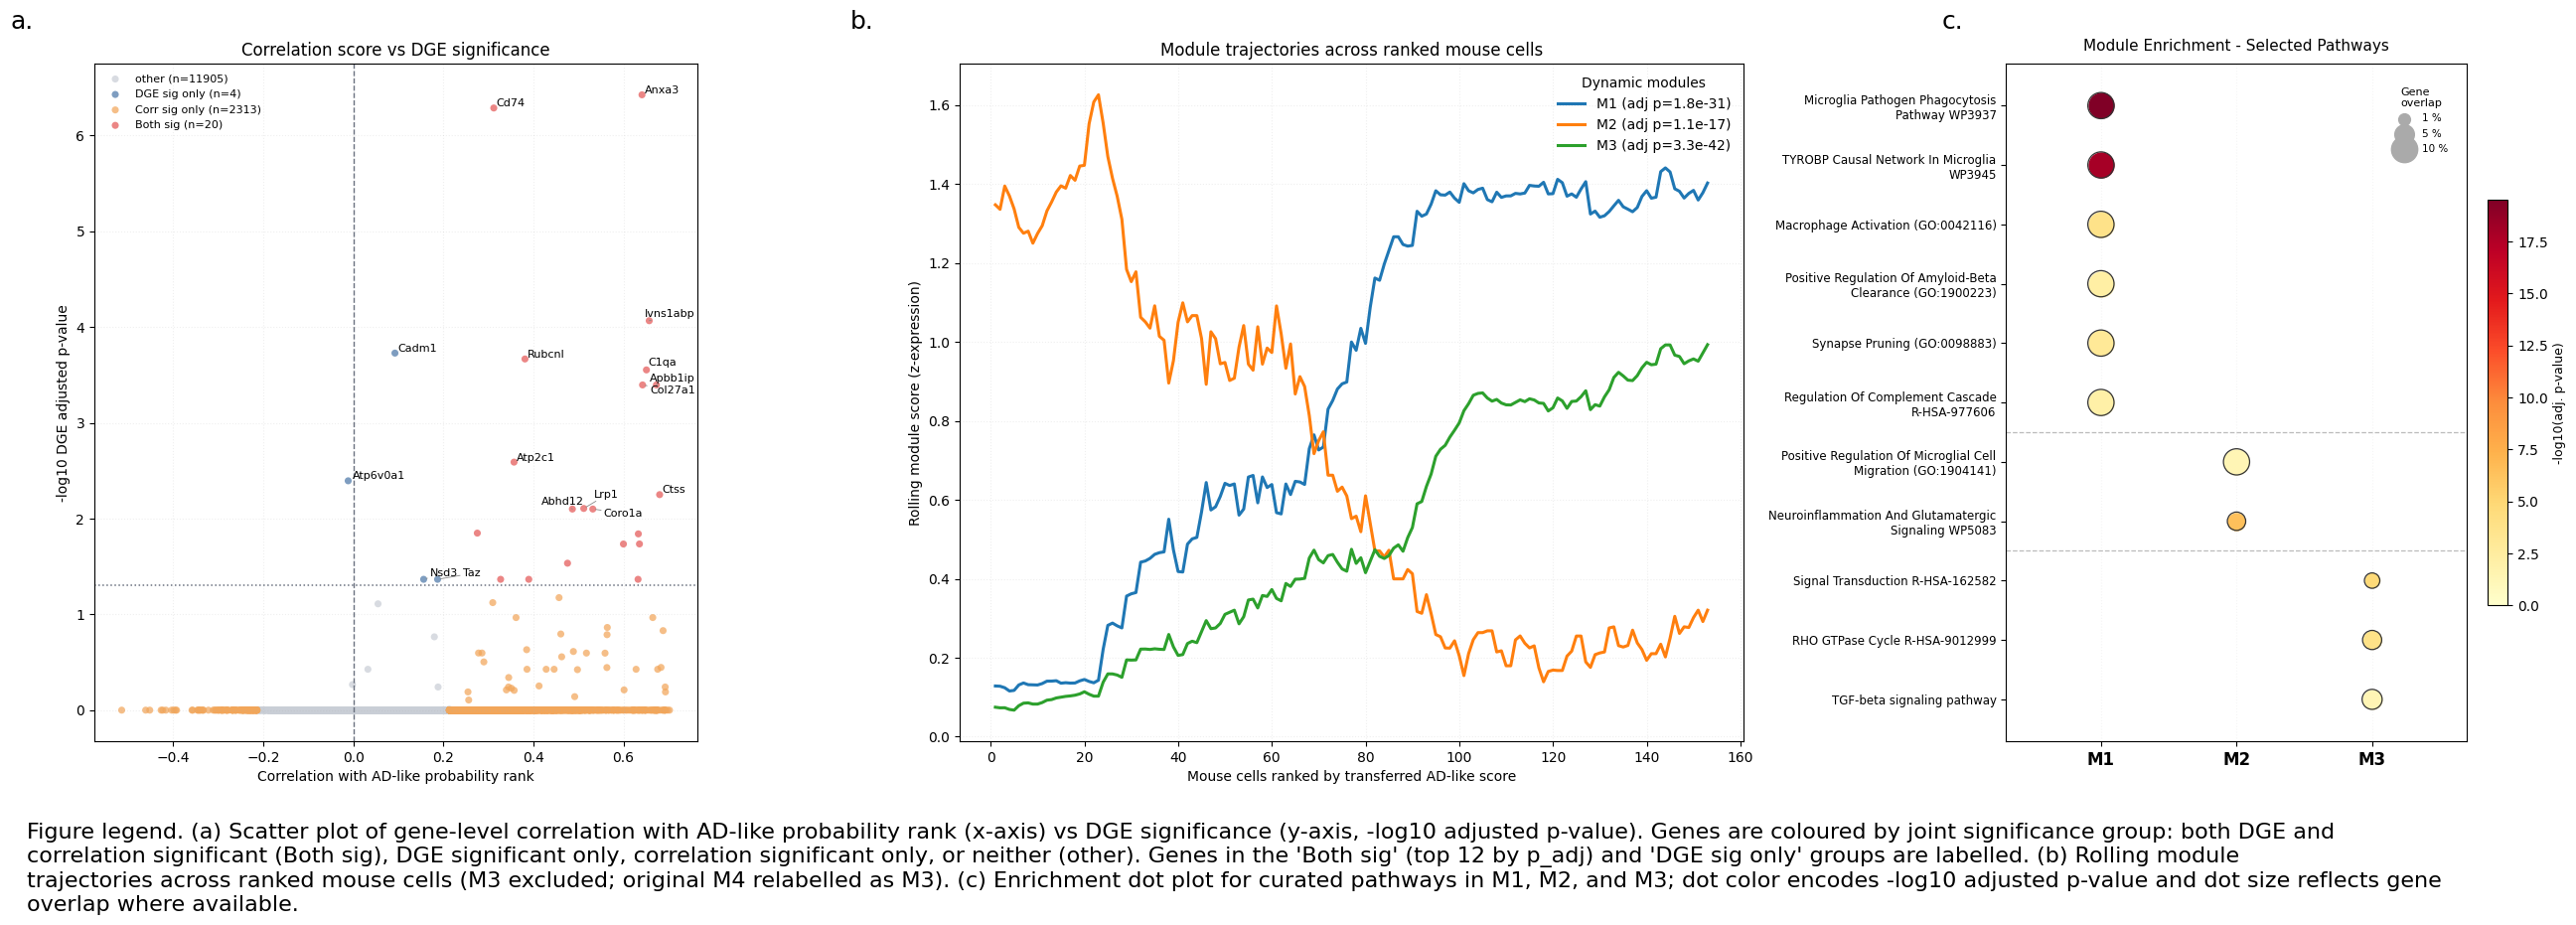

Saved: /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/Plots/AD-trend_Gene-Module_Analysis_nb06.svg
Panel A scatter: Both sig=20, DGE sig only=4, Corr sig only=2313, total genes=14242
Trajectory modules displayed: ['M1', 'M2', 'M4']  (M3 excluded; M4 relabelled -> M3)
All dot-plot terms matched in enrichment results.


In [19]:

"""
Step 4: Three-panel figure.
  Panel A - Correlation vs DGE scatter (3c-i)
  Panel B - Module trajectories (M3 excluded; M4 relabelled M3)
  Panel C - Enrichment dot plot: curated pathway selections for M1, M2, M3
"""

import matplotlib.colors as mcolors
import textwrap

# -- shared helpers ------------------------------------------------------------
def _parse_overlap(val):
    try:
        a, b = str(val).split("/")
        return float(a) / float(b)
    except Exception:
        return np.nan


def _find_best_match(enrich_df, module_id, query):
    sub = enrich_df[enrich_df["gene_set_name"] == module_id].copy()
    if sub.empty:
        return None
    q = query.lower().strip()
    terms_lo = sub["Term"].str.lower().str.strip()
    mask = terms_lo == q
    if mask.any():
        return sub.loc[mask].loc[sub.loc[mask, "Adjusted P-value"].idxmin()]
    prefix = q[:30]
    mask = terms_lo.str.contains(prefix, regex=False)
    if mask.any():
        return sub.loc[mask].loc[sub.loc[mask, "Adjusted P-value"].idxmin()]
    mask = sub["Term"].apply(lambda t: t.lower().strip() in q)
    if mask.any():
        return sub.loc[mask].loc[sub.loc[mask, "Adjusted P-value"].idxmin()]
    return None


def _wrap(s, max_len=38):
    if len(s) <= max_len:
        return s
    for i in range(max_len, -1, -1):
        if s[i] == " ":
            return s[:i] + "\n" + s[i + 1:]
    return s


# -- Panel A: dependency check -------------------------------------------------
assert "compare_df" in dir(), "compare_df not found — run Section 3c-i first"

_scatter_palette = {
    "other": "#C9CED6",
    "DGE sig only": "#4C78A8",
    "Corr sig only": "#F2A65A",
    "Both sig": "#E45756",
}

# -- Panel C: dot plot data ----------------------------------------------------
_DOT_REMAP = {"M1": "M1", "M2": "M2", "M4": "M3"}
CURATED_PATHWAYS = {
    "M1": [
        "Microglia Pathogen Phagocytosis Pathway WP3937",
        "TYROBP Causal Network In Microglia WP3945",
        "Macrophage Activation (GO:0042116)",
        "Positive Regulation Of Amyloid-Beta Clearance (GO:1900223)",
        "Synapse Pruning (GO:0098883)",
        "Regulation Of Complement Cascade R-HSA-977606",
    ],
    "M2": [
        "Positive Regulation Of Microglial Cell Migration (GO:1904141)",
        "Neuroinflammation And Glutamatergic Signaling WP5083",
    ],
    "M4": [  # displayed as M3
        "Signal Transduction R-HSA-162582",
        "RHO GTPase Cycle R-HSA-9012999",
        "TGF-beta signaling pathway",
    ],
}

ok_enrich = enrichment_results_df[enrichment_results_df["status"] == "ok"].copy()
dot_records = []
for raw_mod, pathways in CURATED_PATHWAYS.items():
    display_mod = _DOT_REMAP[raw_mod]
    for pw_label in pathways:
        hit = _find_best_match(ok_enrich, raw_mod, pw_label)
        if hit is not None:
            adj_p = float(hit["Adjusted P-value"])
            dot_records.append(
                {
                    "module_display": display_mod,
                    "pathway_label": pw_label,
                    "adj_pval": adj_p,
                    "neg_log10_adjp": float(-np.log10(max(adj_p, 1e-300))),
                    "overlap_frac": _parse_overlap(hit.get("Overlap", "")),
                    "term_matched": str(hit["Term"]),
                    "found": True,
                }
            )
        else:
            dot_records.append(
                {
                    "module_display": display_mod,
                    "pathway_label": pw_label,
                    "adj_pval": np.nan,
                    "neg_log10_adjp": 0.0,
                    "overlap_frac": np.nan,
                    "term_matched": None,
                    "found": False,
                }
            )
dot_df = pd.DataFrame(dot_records)

module_order = ["M1", "M2", "M3"]
pathway_order = []
for raw_mod in ["M1", "M2", "M4"]:
    pathway_order.extend(CURATED_PATHWAYS[raw_mod])
pathway_order_rev = list(reversed(pathway_order))
n_paths = len(pathway_order_rev)

vmax_nlp = float(np.nanmax(dot_df["neg_log10_adjp"].replace(0.0, np.nan)))
vmax_nlp = max(vmax_nlp if not np.isnan(vmax_nlp) else 2.0, 2.0)
dot_cmap = plt.cm.YlOrRd
dot_norm = mcolors.Normalize(vmin=0, vmax=vmax_nlp)
use_overlap = dot_df["overlap_frac"].notna().sum() > len(dot_df) * 0.3
MIN_S, MAX_S = 40, 360


def _dot_size(row):
    if not row["found"]:
        return MIN_S
    if use_overlap and not np.isnan(row["overlap_frac"]):
        s = MIN_S + min(row["overlap_frac"] * 10.0, 1.0) * (MAX_S - MIN_S)
    else:
        s = MIN_S + (row["neg_log10_adjp"] / vmax_nlp) * (MAX_S - MIN_S)
    return float(np.clip(s, MIN_S, MAX_S))


# -- Figure layout -------------------------------------------------------------
fig, axes = plt.subplots(
    1,
    3,
    figsize=(26, 9),
    gridspec_kw={"width_ratios": [1.0, 1.3, 0.85]},
)
panel_label_xy = (-0.14, 1.08)

# -- Panel A: Correlation vs DGE scatter ---------------------------------------
ax = axes[0]
for label in ["other", "DGE sig only", "Corr sig only", "Both sig"]:
    sub = compare_df[compare_df["joint_group"] == label]
    ax.scatter(
        sub["corr_with_rank"],
        sub["neg_log10_dge_padj"],
        s=26,
        alpha=0.72,
        color=_scatter_palette[label],
        edgecolor="none",
        label=f"{label} (n={len(sub)})",
    )

ax.axvline(0, color="#6B7280", linestyle="--", linewidth=1.0)
ax.axhline(-np.log10(0.05), color="#6B7280", linestyle=":", linewidth=1.1)
ax.set_xlabel("Correlation with AD-like probability rank")
ax.set_ylabel("-log10 DGE adjusted p-value")
ax.set_title("Correlation score vs DGE significance")
ax.legend(frameon=False, fontsize=8)
ax.grid(alpha=0.2, linestyle=":")

_both_sig = compare_df[compare_df["joint_group"] == "Both sig"].nsmallest(12, "p_adj")
_dge_only = compare_df[compare_df["joint_group"] == "DGE sig only"]
_texts_a = []
for _, row in pd.concat([_both_sig, _dge_only], axis=0).iterrows():
    _texts_a.append(
        ax.text(
            float(row["corr_with_rank"]),
            float(row["neg_log10_dge_padj"]),
            str(row["gene"]),
            fontsize=8,
        )
    )
try:
    from adjustText import adjust_text as _adj_txt
    _adj_txt(_texts_a, ax=ax, arrowprops=dict(arrowstyle="-", color="#888888", lw=0.6))
except ImportError:
    pass

ax.annotate("a.", xy=panel_label_xy, xycoords="axes fraction", fontsize=18, ha="left", va="top")

# -- Panel B: Module trajectories ----------------------------------------------
ax = axes[1]
_traj_drop = {"M3"}
_traj_remap = {"M4": "M3"}
module_cols = [c for c in module_score_df.columns if c.startswith("M") and c not in _traj_drop]
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
module_label_map = {}
if "module_summary_df" in globals() and not module_summary_df.empty:
    for _, row in module_summary_df.iterrows():
        orig = row["module"]
        if orig in _traj_drop:
            continue
        display = _traj_remap.get(orig, orig)
        module_label_map[orig] = f"{display} (adj p={row['module_corr_p_adj_bh']:.2g})"
for i, col in enumerate(module_cols):
    y = module_score_df[col]
    win = max(15, len(y) // 25)
    roll = y.rolling(win, center=True, min_periods=max(5, win // 3)).mean()
    ax.plot(
        module_score_df["rank_order"],
        roll,
        linewidth=2.2,
        color=palette[i % len(palette)],
        label=module_label_map.get(col, col),
    )

ax.set_title("Module trajectories across ranked mouse cells")
ax.set_xlabel("Mouse cells ranked by transferred AD-like score")
ax.set_ylabel("Rolling module score (z-expression)")
ax.grid(alpha=0.2, linestyle=":")
ax.legend(title="Dynamic modules", frameon=False)
ax.annotate("b.", xy=panel_label_xy, xycoords="axes fraction", fontsize=18, ha="left", va="top")

# -- Panel C: Enrichment dot plot ----------------------------------------------
ax = axes[2]
for _, row in dot_df.iterrows():
    xi = module_order.index(row["module_display"])
    yi = pathway_order_rev.index(row["pathway_label"])
    s = _dot_size(row)
    if not row["found"]:
        ax.scatter(xi, yi, s=s, color="#E0E0E0", linewidths=0, zorder=2)
    else:
        c = dot_cmap(dot_norm(row["neg_log10_adjp"]))
        ax.scatter(xi, yi, s=s, color=c, linewidths=0, zorder=3)
        if row["adj_pval"] < 0.05:
            ax.scatter(
                xi,
                yi,
                s=s,
                facecolors="none",
                edgecolors="#333333",
                linewidths=0.9,
                zorder=4,
            )

n_m4 = len(CURATED_PATHWAYS["M4"])
n_m2 = len(CURATED_PATHWAYS["M2"])
ax.axhline(n_m4 - 0.5, color="#BBBBBB", lw=0.9, ls="--", zorder=1)
ax.axhline(n_m4 + n_m2 - 0.5, color="#BBBBBB", lw=0.9, ls="--", zorder=1)

ax.set_xticks(range(len(module_order)))
ax.set_xticklabels(module_order, fontsize=12, fontweight="bold")
ax.set_xlim(-0.7, len(module_order) - 0.3)
ax.set_ylim(-0.7, n_paths - 0.3)
ax.grid(axis="x", alpha=0.12, linestyle=":")
ax.set_title("Module Enrichment - Selected Pathways", fontsize=11, pad=10)
ax.set_yticks(range(n_paths))
ax.set_yticklabels([_wrap(p) for p in pathway_order_rev], fontsize=8.5)

sm = plt.cm.ScalarMappable(cmap=dot_cmap, norm=dot_norm)
sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.06, pad=0.04, shrink=0.6)
cb.set_label("-log10(adj. p-value)", fontsize=9)

if use_overlap:
    for frac, lbl in [(0.01, "1 %"), (0.05, "5 %"), (0.10, "10 %")]:
        s = float(np.clip(MIN_S + min(frac * 10.0, 1.0) * (MAX_S - MIN_S), MIN_S, MAX_S))
        ax.scatter([], [], s=s, color="#AAAAAA", label=lbl)
    ax.legend(
        title="Gene\noverlap",
        frameon=False,
        fontsize=7.5,
        title_fontsize=8,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        bbox_transform=ax.transAxes,
    )
else:
    for lv in sorted({1, 2, int(round(vmax_nlp))}):
        s = float(np.clip(MIN_S + (lv / vmax_nlp) * (MAX_S - MIN_S), MIN_S, MAX_S))
        ax.scatter([], [], s=s, color="#AAAAAA", label=str(lv))
    ax.legend(
        title="-log10(p)",
        frameon=False,
        fontsize=7.5,
        title_fontsize=8,
        loc="upper right",
        bbox_to_anchor=(0.98, 0.98),
        bbox_transform=ax.transAxes,
    )
ax.annotate("c.", xy=panel_label_xy, xycoords="axes fraction", fontsize=18, ha="left", va="top")

# -- Final layout --------------------------------------------------------------
# fig.suptitle(
#     "Step 3: Gene-level and module-level dynamics along transferred AD-like rank",
#     fontsize=15,
#     y=1.02,
# )

figure_legend = textwrap.fill(
    "Figure legend. (a) Scatter plot of gene-level correlation with AD-like probability rank (x-axis) vs "
    "DGE significance (y-axis, -log10 adjusted p-value). Genes are coloured by joint significance group: "
    "both DGE and correlation significant (Both sig), DGE significant only, correlation significant only, "
    "or neither (other). Genes in the 'Both sig' (top 12 by p_adj) and 'DGE sig only' groups are labelled. "
    "(b) Rolling module trajectories across ranked mouse cells (M3 excluded; original M4 relabelled as M3). "
    "(c) Enrichment dot plot for curated pathways in M1, M2, and M3; dot color encodes -log10 adjusted p-value and dot size reflects gene overlap where available.",
    width=220,
)
fig.text(
    0.01,
    -0.05,
    figure_legend,
    ha="left",
    va="bottom",
    fontsize=16,
    style="normal",
    linespacing=1.25,
)

plt.tight_layout(rect=[0, 0.08, 1, 0.98])
plt.show()

_fig_out = analysis_root_path / "Results" / "Plots" / "AD-trend_Gene-Module_Analysis_nb06.svg"
fig.savefig(_fig_out, format="svg", dpi=300, bbox_inches="tight")  # DEMO
print(f"Saved: {_fig_out}")  # DEMO

_n_both = int((compare_df["joint_group"] == "Both sig").sum())
_n_dge = int((compare_df["joint_group"] == "DGE sig only").sum())
_n_corr = int((compare_df["joint_group"] == "Corr sig only").sum())
print(f"Panel A scatter: Both sig={_n_both}, DGE sig only={_n_dge}, Corr sig only={_n_corr}, total genes={len(compare_df)}")
print(f"Trajectory modules displayed: {module_cols}  (M3 excluded; M4 relabelled -> M3)")
not_found = dot_df[~dot_df["found"]]
if not not_found.empty:
    print("\nPaths not matched in enrichment results (shown as grey dots):")
    for _, r in not_found.iterrows():
        print(f"  [{r['module_display']}] {r['pathway_label']}")
else:
    print("All dot-plot terms matched in enrichment results.")


## Final Output Manifest

The cell below records publication-facing outputs produced by this notebook and checks their existence on disk.

In [20]:
"""
Final manifest: report key output artifacts produced by Notebook 06.
"""

analysis_root_path = Path(ANALYSIS_ROOT) if isinstance(ANALYSIS_ROOT, str) else ANALYSIS_ROOT

output_manifest = [
    {
        "artifact": "Step 2 expression figure (SVG)",
        "path": analysis_root_path / "Results" / "Plots" / "mouse_homeostatic+subtype_c1qa_expression_nb06.svg",
        "stage": "Section 1",
    },
    {
        "artifact": "Step 2 transfer figure (SVG)",
        "path": analysis_root_path / "Results" / "Plots" / "mouse_RollingC1qaExpression_nn_probability_transfer_nb06.svg",
        "stage": "Step 2c",
    },
    {
        "artifact": "Mouse AD-like probabilities (CSV)",
        "path": analysis_root_path / "Microglia_analysis" / "mouse_ad_like_probabilities_with_barcodes_nb06.csv",
        "stage": "Step 2d",
    },
    {
        "artifact": "Model bundle (joblib)",
        "path": analysis_root_path / "Microglia_analysis" / "model" / "human_to_mouse_adlike_mlp_model_bundle_nb06.joblib",
        "stage": "Step 2d",
    },
    {
        "artifact": "Model description (JSON)",
        "path": analysis_root_path / "Microglia_analysis" / "model" / "human_to_mouse_adlike_mlp_model_description_nb06.json",
        "stage": "Step 2d",
    },
    {
        "artifact": "Enrichment workbook (XLSX)",
        "path": analysis_root_path / "Results" / "Tables" / "Microglia_1.5_enrichment_workbook_nb06.xlsx",
        "stage": "Step 3c export",
    },
]

manifest_rows = []
for item in output_manifest:
    out_path = Path(item["path"])
    exists = out_path.exists()
    size_kb = (out_path.stat().st_size / 1024.0) if exists else None
    manifest_rows.append(
        {
            "stage": item["stage"],
            "artifact": item["artifact"],
            "exists": exists,
            "size_kb": round(size_kb, 1) if size_kb is not None else None,
            "path": str(out_path),
        }
    )

manifest_df = pd.DataFrame(manifest_rows)

print("=" * 88)
print("Notebook 06 final output manifest")
print("=" * 88)
print(
    manifest_df[["stage", "artifact", "exists", "size_kb"]].to_string(
        index=False,
        na_rep="NA",
    )
)

missing_outputs = manifest_df.loc[~manifest_df["exists"], "artifact"].tolist()
if missing_outputs:
    print("\nMissing outputs:")
    for name in missing_outputs:
        print(f"  - {name}")
else:
    print("\nAll listed publication outputs are present.")

print("\nOutput paths:")
for _, row in manifest_df.iterrows():
    print(f"  - {row['artifact']}: {row['path']}")

Notebook 06 final output manifest
         stage                          artifact  exists  size_kb
     Section 1    Step 2 expression figure (SVG)    True   2700.3
       Step 2c      Step 2 transfer figure (SVG)    True    268.1
       Step 2d Mouse AD-like probabilities (CSV)    True     20.7
       Step 2d             Model bundle (joblib)    True   7184.9
       Step 2d          Model description (JSON)    True      2.2
Step 3c export        Enrichment workbook (XLSX)    True   1988.3

All listed publication outputs are present.

Output paths:
  - Step 2 expression figure (SVG): /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/Plots/mouse_homeostatic+subtype_c1qa_expression_nb06.svg
  - Step 2 transfer figure (SVG): /media/drive_c/Project_Brain_snRNAseq/Analysis/Results/Plots/mouse_RollingC1qaExpression_nn_probability_transfer_nb06.svg
  - Mouse AD-like probabilities (CSV): /media/drive_c/Project_Brain_snRNAseq/Analysis/Microglia_analysis/mouse_ad_like_probabilities_with_ba